# Exp1 GAUSSIAN DDPM Evaluation

DDPM inference and morphology evaluation on the Exp1 GAUSSIAN dataset.
Inputs are the standard two-channel paired dataset:
`EXP1GAUSSIAN_1000_64_poissonexcess.npy` with `data[:, 0] = GT`, `data[:, 1] = poissonexcess`.

Confidence phase diagram: 2D over `flux_F0` × `scale_r39_deg`.
Per sample, GT and SR centers + extents are extracted with the same image-moment
function so that the 0.1 deg/pixel rasterization systematic is captured as an error bar.

In [1]:
from pathlib import Path
import csv
import importlib
import json
import math
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.ndimage import map_coordinates
from torchmetrics.image import MultiScaleStructuralSimilarityIndexMeasure as MS_SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "codes").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing both codes/ and data/.")


ADDR_ROOT = find_repo_root()
ADDR_CODE = ADDR_ROOT / "codes"
ADDR_MODELS = ADDR_CODE / "models"
for path in [ADDR_ROOT, ADDR_CODE, ADDR_MODELS]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

from codes.config.config_DDPM import ModelConfig

print(f"ADDR_ROOT = {ADDR_ROOT}")
print(f"ADDR_CODE = {ADDR_CODE}")
print(f"CUDA available = {torch.cuda.is_available()}")


ADDR_ROOT = /root/LHAI_KM2A
ADDR_CODE = /root/LHAI_KM2A/codes
CUDA available = True


/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUN_LABEL = "Exp1_GAUSSIAN"

DATA_DIR = ADDR_ROOT / "data" / "Evaluation" / "Exp1_ParametricMorphologyReconstruction"
DATA_NAME = "EXP1GAUSSIAN_1000_64_poissonexcess.npy"

MODEL_WEIGHT_DIR = ADDR_ROOT / "saves" / "MODEL" / "DDPM"
MODEL_WEIGHT_NAME = "Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.pth"

DIFFUSION_CONFIG_KEY = "DDPM_64"
DIFFUSION_MODULE_NAME = "DDPM"
DIFFUSION_CLASS_NAME = "DDPM"

UNET_CONFIG_KEY = "UNET"
UNET_MODULE_NAME = "UNET"
UNET_CLASS_NAME = "UNET"

DATA_RANGE = 2.0
COUNTS_RESTORE_MODE_FOR_METRICS = "input_mass_match"
COUNTS_RESTORE_MODE_FOR_VISUAL = "input_mass_match"
CLIP_FOR_COUNTS = True
EPS_COUNTS = 1e-8

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRICT_LOAD = True
CLAMP_OUTPUT = False
OVERRIDE_IMG_SIZE_FROM_DATA = True

EVAL_INDICES = None
EVAL_START = 0
EVAL_STOP = 999
EVAL_STEP = 1
INFERENCE_BATCH_SIZE = 100
SAMPLING_SEED = 0

VIS_INDICES = [0,2,5,8,10,15,20,25,30,35,40,45,49]
LINE_SEGMENTS = {}

SAVE_OUTPUTS = True
OUTPUT_DIR = ADDR_ROOT / "saves" / "EVAL" / "Exp1_ParametricMorphologyReconstruction" / "GAUSSIAN"

# Exp1 metadata file with construction truth (flux, r39, Cx, Cy, ROI)
EXP1_PARAM_JSON = DATA_DIR / "exp1_parameters.json"
EXP1_SOURCE_TYPE = "GAUSSIAN"


In [3]:
TRAIN_DATASET_NAMES = [
    "SR4bkgon_3198_64_train.npy",
    "SR4bkgon_3198_128_train.npy",
    "SR4excess_3198_64_train.npy",
    "SR4excess_3198_128_train.npy",
    "SR4poisonon_3198_64_train.npy",
    "SR4poisonon_3198_128_train.npy",
]


def show_available_files():
    data_files = sorted(DATA_DIR.glob("*.npy")) if DATA_DIR.exists() else []
    weight_files = sorted(MODEL_WEIGHT_DIR.glob("*.pth")) if MODEL_WEIGHT_DIR.exists() else []
    print("Available data files:")
    for path in data_files:
        print(f"  {path.name}")
    if not data_files:
        print(f"  No .npy files found in {DATA_DIR}")
    print("\nAvailable DDPM weights:")
    for path in weight_files:
        print(f"  {path.name}")
    if not weight_files:
        print(f"  No .pth files found in {MODEL_WEIGHT_DIR}")
    print("\nConfig hints:")
    print("  64x64 deconvolution: DIFFUSION_CONFIG_KEY = 'DDPM_64'")
    print("  128x128 SR+deconvolution: DIFFUSION_CONFIG_KEY = 'DDPM128'")


show_available_files()

if DATA_NAME is None:
    raise ValueError("Set DATA_NAME in the configuration cell, then rerun from this cell.")
if MODEL_WEIGHT_NAME is None:
    raise ValueError("Set MODEL_WEIGHT_NAME in the configuration cell, then rerun from this cell.")

data_path = DATA_DIR / DATA_NAME
model_weight_path = MODEL_WEIGHT_DIR / MODEL_WEIGHT_NAME
if not data_path.exists():
    raise FileNotFoundError(data_path)
if not model_weight_path.exists():
    raise FileNotFoundError(model_weight_path)

print(f"Selected data: {data_path}")
print(f"Selected weight: {model_weight_path}")


Available data files:
  EXP1DIFFUSION_1000_128_GT.npy
  EXP1DIFFUSION_1000_64_GT.npy
  EXP1DIFFUSION_1000_64_RESPONSE.npy
  EXP1DISK_1000_128_GT.npy
  EXP1DISK_1000_64_GT.npy
  EXP1DISK_1000_64_RESPONSE.npy
  EXP1DISK_1000_64_poissonexcess.npy
  EXP1GAUSSIAN_1000_128_GT.npy
  EXP1GAUSSIAN_1000_64_GT.npy
  EXP1GAUSSIAN_1000_64_RESPONSE.npy
  EXP1GAUSSIAN_1000_64_poissonexcess.npy
  EXP1POINT_50_128_GT.npy
  EXP1POINT_50_64_GT.npy
  EXP1POINT_50_64_RESPONSE.npy
  EXP1POINT_50_64_poissonexcess.npy
  EXP1SHELL_1000_128_GT.npy
  EXP1SHELL_1000_64_GT.npy
  EXP1SHELL_1000_64_RESPONSE.npy

Available DDPM weights:
  Best_DDPM_EXP01_2epo_32bth_SR4poissonexcess.pth
  Best_DDPM_EXP01_400epo_128bth_KM2A4eval.pth
  Best_DDPM_KM2A_1000epo_32bth_SR4poissonexcess.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonon.pth
  Best_DDPM_KM2A_finetune_200epo.pth
  Best_KM2AEXP1GAUSSIAN_finetune.pth
  Last_DDPM_EXP01_2epo_32bth_SR4poissonexcess.pth
  Last_DDPM_EXP01

In [4]:
def _ensure_nchw(images):
    images = np.asarray(images)
    if images.ndim == 3:
        images = images[:, None, :, :]
    if images.ndim == 4:
        return images.astype(np.float32, copy=False)
    raise ValueError(f"Expected image array with shape (N,H,W) or (N,C,H,W), got {images.shape}")


def load_pair_arrays(path):
    data = np.load(path, allow_pickle=True)
    if data.ndim >= 4 and data.shape[1] >= 2:
        targets = np.stack(data[:, 0])
        inputs = np.stack(data[:, 1])
    elif data.ndim == 2 and data.shape[1] >= 2:
        targets = np.stack(data[:, 0])
        inputs = np.stack(data[:, 1])
    else:
        raise ValueError(
            "Expected paired dataset where data[:,0] is GT/target and data[:,1] is input/response. "
            f"Got shape {data.shape}."
        )
    return _ensure_nchw(inputs), _ensure_nchw(targets)


def minmax_stats_per_image(images):
    flat = images.reshape(images.shape[0], -1)
    mins = flat.min(axis=1).reshape((-1, 1, 1, 1)).astype(np.float32)
    maxs = flat.max(axis=1).reshape((-1, 1, 1, 1)).astype(np.float32)
    return mins, maxs


def normalize_from_stats(images, mins, maxs, data_range=1.0):
    norm01 = (images.astype(np.float32, copy=False) - mins) / np.maximum(maxs - mins, 1e-8)
    if abs(data_range - 1.0) < 1e-6:
        return norm01.astype(np.float32, copy=False)
    if abs(data_range - 2.0) < 1e-6:
        return (2.0 * norm01 - 1.0).astype(np.float32, copy=False)
    raise ValueError("DATA_RANGE must be 1.0 or 2.0")


def resize_numpy_batch(batch, size):
    batch = np.asarray(batch, dtype=np.float32)
    if batch.shape[-2:] == (size, size):
        return batch
    tensor = torch.from_numpy(batch).float()
    return F.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False).numpy()


raw_inputs_np, raw_targets_np = load_pair_arrays(data_path)
input_mins, input_maxs = minmax_stats_per_image(raw_inputs_np)
target_mins, target_maxs = minmax_stats_per_image(raw_targets_np)
inputs_np = normalize_from_stats(raw_inputs_np, input_mins, input_maxs, DATA_RANGE)
targets_np = normalize_from_stats(raw_targets_np, target_mins, target_maxs, DATA_RANGE)

if inputs_np.shape[0] != targets_np.shape[0]:
    raise ValueError("Input/target sample counts differ.")
if inputs_np.shape[1] != targets_np.shape[1]:
    raise ValueError("Input/target channel counts differ.")

print(f"raw input shape  = {raw_inputs_np.shape}")
print(f"raw target shape = {raw_targets_np.shape}")
print(f"raw input range  = ({raw_inputs_np.min():.4g}, {raw_inputs_np.max():.4g})")
print(f"raw target range = ({raw_targets_np.min():.4g}, {raw_targets_np.max():.4g})")
print(f"model input shape  = {inputs_np.shape}, range=({inputs_np.min():.4g}, {inputs_np.max():.4g})")
print(f"model target shape = {targets_np.shape}, range=({targets_np.min():.4g}, {targets_np.max():.4g})")


raw input shape  = (1000, 1, 64, 64)
raw target shape = (1000, 1, 64, 64)
raw input range  = (-10.07, 337)
raw target range = (0, 0.2759)
model input shape  = (1000, 1, 64, 64), range=(-1, 1)
model target shape = (1000, 1, 64, 64), range=(-1, 1)


In [5]:
def import_model_class(module_name, class_name):
    module = importlib.import_module(f"codes.models.{module_name}")
    return getattr(module, class_name)


model_cfg = ModelConfig()
model_params = model_cfg.model_params
image_size = int(targets_np.shape[-1])
if targets_np.shape[-1] != targets_np.shape[-2]:
    raise ValueError(f"Target images must be square for current DDPM implementation, got {targets_np.shape[-2:]}")

if DIFFUSION_CONFIG_KEY is None:
    if image_size == 128 and "DDPM128" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM128"
    elif image_size == 64 and "DDPM_64" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM_64"
    elif "DDPM" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM"
    else:
        raise KeyError("Could not infer DIFFUSION_CONFIG_KEY. Set it manually.")

if DIFFUSION_CONFIG_KEY not in model_params:
    raise KeyError(f"{DIFFUSION_CONFIG_KEY=} not found in ModelConfig.model_params")
if UNET_CONFIG_KEY not in model_params:
    raise KeyError(f"{UNET_CONFIG_KEY=} not found in ModelConfig.model_params")

params_diffusion = dict(model_params[DIFFUSION_CONFIG_KEY])
params_unet = dict(model_params[UNET_CONFIG_KEY])
if OVERRIDE_IMG_SIZE_FROM_DATA and params_diffusion.get("img_size") != image_size:
    print(f"Overriding diffusion img_size from {params_diffusion.get('img_size')} to data target size {image_size}.")
    params_diffusion["img_size"] = image_size
params_diffusion["device"] = torch.device(DEVICE)

torch.manual_seed(SAMPLING_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SAMPLING_SEED)

device = torch.device(DEVICE)
DIFFUSION = import_model_class(DIFFUSION_MODULE_NAME, DIFFUSION_CLASS_NAME)
UNET = import_model_class(UNET_MODULE_NAME, UNET_CLASS_NAME)

diffusion = DIFFUSION(**params_diffusion)
unet = UNET(**params_unet).to(device)
if hasattr(unet, "build"):
    unet.build()
unet.to(device)
state = torch.load(model_weight_path, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
unet.load_state_dict(state, strict=STRICT_LOAD)
unet.eval()

print(f"Device: {device}")
print(f"Diffusion config key: {DIFFUSION_CONFIG_KEY}")
print(f"Diffusion class: {DIFFUSION_MODULE_NAME}.{DIFFUSION_CLASS_NAME}")
print(f"UNET config/class: {UNET_CONFIG_KEY} / {UNET_MODULE_NAME}.{UNET_CLASS_NAME}")
print(f"Image size: {image_size}")


Device: cuda
Diffusion config key: DDPM_64
Diffusion class: DDPM.DDPM
UNET config/class: UNET / UNET.UNET
Image size: 64


In [6]:
def select_eval_indices(total, explicit=None, start=0, stop=None, step=1):
    if explicit is not None:
        indices = np.asarray(explicit, dtype=int)
    else:
        stop = total if stop is None else min(int(stop), total)
        indices = np.arange(int(start), stop, int(step), dtype=int)
    if indices.size == 0:
        raise ValueError("No evaluation indices selected.")
    if indices.min() < 0 or indices.max() >= total:
        raise IndexError(f"Selected indices must be in [0, {total - 1}], got {indices.min()}..{indices.max()}.")
    return indices


def tensor_from_numpy_batch(array, indices):
    return torch.from_numpy(array[indices]).float()


def resize_to_model_size(batch):
    if batch.shape[-2:] == (image_size, image_size):
        return batch
    return F.interpolate(batch, size=(image_size, image_size), mode="bilinear", align_corners=False)


def maybe_clamp(batch):
    if not CLAMP_OUTPUT:
        return batch
    if abs(DATA_RANGE - 1.0) < 1e-6:
        return batch.clamp(0.0, 1.0)
    return batch.clamp(-1.0, 1.0)


def reduce_generated(generated, batch_size):
    if generated.dim() == 5:
        if generated.shape[0] == batch_size:
            generated = generated[:, -1]
        else:
            generated = generated[-1]
    return maybe_clamp(generated)


@torch.no_grad()
def generate_batch(input_batch):
    input_batch = resize_to_model_size(input_batch.to(device))
    torch.manual_seed(SAMPLING_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SAMPLING_SEED)
    generated = diffusion.reverse_diffusion(
        model=unet,
        n_images=input_batch.shape[0],
        n_channels=input_batch.shape[1],
        input_image=input_batch,
        save_time_steps=None,
    )
    return reduce_generated(generated, input_batch.shape[0])


def normalized_to_unit_interval(array):
    array = np.asarray(array, dtype=np.float32)
    if abs(DATA_RANGE - 2.0) < 1e-6:
        unit = 0.5 * (array + 1.0)
    elif abs(DATA_RANGE - 1.0) < 1e-6:
        unit = array
    else:
        raise ValueError("DATA_RANGE must be 1.0 or 2.0")
    return np.clip(unit, 0.0, 1.0) if CLIP_FOR_COUNTS else unit


def _stats_for_indices(mins, maxs, indices):
    return mins[indices], maxs[indices]


def restore_counts_from_normalized(norm_batch, *, reference_counts=None, mins=None, maxs=None, mode="mass_match"):
    norm_batch = np.asarray(norm_batch, dtype=np.float32)
    unit = normalized_to_unit_interval(norm_batch)
    if mode == "minmax":
        if mins is None or maxs is None:
            raise ValueError("minmax restore requires mins and maxs.")
        return unit * np.maximum(maxs - mins, EPS_COUNTS) + mins
    if mode == "mass_match":
        if reference_counts is None:
            raise ValueError("mass_match restore requires reference_counts.")
        unit = np.clip(unit, 0.0, None)
        reference = np.clip(reference_counts.astype(np.float32, copy=False), 0.0, None)
        unit_mass = unit.reshape(unit.shape[0], -1).sum(axis=1).reshape((-1, 1, 1, 1))
        reference_mass = reference.reshape(reference.shape[0], -1).sum(axis=1).reshape((-1, 1, 1, 1))
        return unit * (reference_mass / np.maximum(unit_mass, EPS_COUNTS))
    raise ValueError("mode must be 'minmax' or 'mass_match'.")


def restore_generated_counts(norm_batch, indices, mode):
    indices = np.asarray(indices, dtype=int)
    if mode == "target_minmax":
        mins, maxs = _stats_for_indices(target_mins, target_maxs, indices)
        return restore_counts_from_normalized(norm_batch, mins=mins, maxs=maxs, mode="minmax")
    if mode == "input_minmax":
        mins, maxs = _stats_for_indices(input_mins, input_maxs, indices)
        return restore_counts_from_normalized(norm_batch, mins=mins, maxs=maxs, mode="minmax")
    if mode == "target_mass_match":
        return restore_counts_from_normalized(
            norm_batch,
            reference_counts=raw_target_counts_reference(indices),
            mode="mass_match",
        )
    if mode == "input_mass_match":
        return restore_counts_from_normalized(
            norm_batch,
            reference_counts=raw_input_counts(indices),
            mode="mass_match",
        )
    raise ValueError("Restore mode must be one of: target_minmax, input_minmax, target_mass_match, input_mass_match")


def raw_input_counts(indices):
    return resize_numpy_batch(raw_inputs_np[np.asarray(indices, dtype=int)], image_size)


def raw_target_counts_reference(indices):
    return resize_numpy_batch(raw_targets_np[np.asarray(indices, dtype=int)], image_size)


def raw_target_counts(indices):
    indices = np.asarray(indices, dtype=int)
    target_norm = resize_numpy_batch(targets_np[indices], image_size)
    return restore_counts_from_normalized(
        target_norm,
        reference_counts=raw_target_counts_reference(indices),
        mode="mass_match",
    )


def safe_metric(metric, pred, target):
    try:
        return float(metric(pred, target).detach().cpu().item())
    except Exception as exc:
        print(f"Metric {metric.__class__.__name__} failed for one image: {exc}")
        return float("nan")


def positive_mass(array):
    return float(np.clip(np.asarray(array, dtype=np.float64), 0.0, None).sum())


def pearson_corr(pred, target):
    pred = np.asarray(pred).reshape(-1).astype(np.float64)
    target = np.asarray(target).reshape(-1).astype(np.float64)
    if np.std(pred) < 1e-12 or np.std(target) < 1e-12:
        return float("nan")
    return float(np.corrcoef(pred, target)[0, 1])


def peak_distance(pred, target):
    pred = np.asarray(pred)
    target = np.asarray(target)
    pred_yx = np.unravel_index(int(np.nanargmax(pred)), pred.shape)
    target_yx = np.unravel_index(int(np.nanargmax(target)), target.shape)
    return float(np.hypot(pred_yx[0] - target_yx[0], pred_yx[1] - target_yx[1]))


def weighted_centroid(image):
    image = np.clip(np.asarray(image, dtype=np.float64), 0.0, None)
    total = image.sum()
    if total <= EPS_COUNTS:
        return np.array([np.nan, np.nan], dtype=np.float64)
    yy, xx = np.indices(image.shape)
    return np.array([(yy * image).sum() / total, (xx * image).sum() / total], dtype=np.float64)


def centroid_distance(pred, target):
    pred_c = weighted_centroid(pred)
    target_c = weighted_centroid(target)
    if np.any(~np.isfinite(pred_c)) or np.any(~np.isfinite(target_c)):
        return float("nan")
    return float(np.linalg.norm(pred_c - target_c))


def poisson_deviance_per_pixel(pred, target):
    pred = np.clip(np.asarray(pred, dtype=np.float64), EPS_COUNTS, None)
    target = np.clip(np.asarray(target, dtype=np.float64), 0.0, None)
    term = pred - target
    mask = target > 0
    term[mask] += target[mask] * np.log(target[mask] / pred[mask])
    return float(2.0 * np.sum(term) / target.size)


def reduced_chi_square(pred, target):
    pred = np.clip(np.asarray(pred, dtype=np.float64), 0.0, None)
    target = np.clip(np.asarray(target, dtype=np.float64), 0.0, None)
    return float(np.mean((pred - target) ** 2 / np.maximum(target, 1.0)))


def image_metrics_normalized(pred, target, source, image_index, ms_ssim_metric, ssim_metric, psnr_metric):
    pred = pred.unsqueeze(0).to(device)
    target = target.unsqueeze(0).to(device)
    diff = pred - target
    rmse = torch.sqrt(torch.mean(diff ** 2)).item()
    target_range = (target.max() - target.min()).clamp(min=1e-8).item()
    mae = torch.mean(torch.abs(diff)).item()
    pred_np = pred.squeeze().detach().cpu().numpy()
    target_np = target.squeeze().detach().cpu().numpy()
    return {
        "image_index": int(image_index),
        "source": source,
        "NRMSE": float(rmse / target_range),
        "RMSE": float(rmse),
        "MAE": float(mae),
        "MS-SSIM": safe_metric(ms_ssim_metric, pred, target),
        "SSIM": safe_metric(ssim_metric, pred, target),
        "PSNR": safe_metric(psnr_metric, pred, target),
        "Pearson": pearson_corr(pred_np, target_np),
        "PeakDistancePx": peak_distance(pred_np, target_np),
    }


def image_metrics_counts(pred, target, source, image_index):
    pred = np.asarray(pred, dtype=np.float64).squeeze()
    target = np.asarray(target, dtype=np.float64).squeeze()
    diff = pred - target
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    abs_target_sum = float(np.sum(np.abs(target)))
    target_positive_sum = positive_mass(target)
    pred_positive_sum = positive_mass(pred)
    return {
        "image_index": int(image_index),
        "source": source,
        "CountMAE": mae,
        "CountRMSE": rmse,
        "CountNMAE": float(np.sum(np.abs(diff)) / (abs_target_sum + EPS_COUNTS)),
        "CountNRMSEMean": float(rmse / (np.mean(np.abs(target)) + EPS_COUNTS)),
        "FluxRelErr": float((pred_positive_sum - target_positive_sum) / (abs(target_positive_sum) + EPS_COUNTS)),
        "AbsFluxRelErr": float(abs(pred_positive_sum - target_positive_sum) / (abs(target_positive_sum) + EPS_COUNTS)),
        "Pearson": pearson_corr(pred, target),
        "PeakDistancePx": peak_distance(pred, target),
        "CentroidDistancePx": centroid_distance(pred, target),
        "PoissonDeviancePerPixel": poisson_deviance_per_pixel(pred, target),
        "ReducedChiSquare": reduced_chi_square(pred, target),
    }


def run_evaluations(indices):
    ms_ssim_metric = MS_SSIM(data_range=DATA_RANGE, kernel_size=7, betas=(0.0448, 0.2856, 0.3001)).to(device)
    ssim_metric = SSIM(data_range=DATA_RANGE).to(device)
    psnr_metric = PSNR(data_range=DATA_RANGE).to(device)
    normalized_rows = []
    counts_rows = []
    generated_cache = {}
    for batch_start in tqdm(range(0, len(indices), INFERENCE_BATCH_SIZE), desc="DDPM evaluation batches"):
        batch_indices = indices[batch_start : batch_start + INFERENCE_BATCH_SIZE]
        inputs = tensor_from_numpy_batch(inputs_np, batch_indices)
        targets = tensor_from_numpy_batch(targets_np, batch_indices)
        inputs_model = resize_to_model_size(inputs).to(device)
        targets_model = resize_to_model_size(targets).to(device)
        generated = generate_batch(inputs)
        generated_np = generated.detach().cpu().numpy()
        input_counts = raw_input_counts(batch_indices)
        target_counts = raw_target_counts(batch_indices)
        generated_counts = restore_generated_counts(generated_np, batch_indices, COUNTS_RESTORE_MODE_FOR_METRICS)
        for local_i, image_index in enumerate(batch_indices):
            image_index = int(image_index)
            normalized_rows.append(image_metrics_normalized(inputs_model[local_i], targets_model[local_i], "input", image_index, ms_ssim_metric, ssim_metric, psnr_metric))
            normalized_rows.append(image_metrics_normalized(generated[local_i], targets_model[local_i], "generated", image_index, ms_ssim_metric, ssim_metric, psnr_metric))
            counts_rows.append(image_metrics_counts(input_counts[local_i], target_counts[local_i], "input", image_index))
            counts_rows.append(image_metrics_counts(generated_counts[local_i], target_counts[local_i], "generated", image_index))
            generated_cache[image_index] = generated_np[local_i]
        del inputs, targets, inputs_model, targets_model, generated
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return normalized_rows, counts_rows, generated_cache


def summarize_rows(rows):
    metrics = [k for k in rows[0].keys() if k not in {"image_index", "source"}]
    summary = {}
    for source in sorted({row["source"] for row in rows}):
        source_rows = [row for row in rows if row["source"] == source]
        summary[source] = {}
        for metric in metrics:
            values = np.asarray([row[metric] for row in source_rows], dtype=np.float64)
            summary[source][metric] = {"mean": float(np.nanmean(values)), "std": float(np.nanstd(values))}
    return summary


def print_normalized_summary(summary, n_images):
    for source in ["generated", "input"]:
        if source not in summary:
            continue
        print(f"\n=== Normalized-space metrics on {n_images} {source} images ===")
        for metric in ["NRMSE", "MAE", "MS-SSIM", "SSIM", "PSNR", "Pearson", "PeakDistancePx"]:
            value = summary[source][metric]["mean"]
            std = summary[source][metric]["std"]
            print(f"{metric:<18} {value: .6f}  +/- {std:.6f}")


def print_counts_summary(summary, n_images):
    print(f"\nCounts restore mode for generated outputs: {COUNTS_RESTORE_MODE_FOR_METRICS}")
    for source in ["generated", "input"]:
        if source not in summary:
            continue
        print(f"\n=== Counts-space/application metrics on {n_images} {source} images ===")
        for metric in ["CountNMAE", "CountNRMSEMean", "AbsFluxRelErr", "FluxRelErr", "Pearson", "PeakDistancePx", "CentroidDistancePx", "PoissonDeviancePerPixel", "ReducedChiSquare"]:
            value = summary[source][metric]["mean"]
            std = summary[source][metric]["std"]
            print(f"{metric:<24} {value: .6f}  +/- {std:.6f}")


def save_evaluation_outputs(normalized_rows, counts_rows, normalized_summary, counts_summary, indices):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}__{indices[0]}_{indices[-1]}"
    norm_csv_path = OUTPUT_DIR / f"normalized_metrics_per_image__{stem}.csv"
    counts_csv_path = OUTPUT_DIR / f"counts_metrics_per_image__{stem}.csv"
    summary_path = OUTPUT_DIR / f"metrics_summary__{stem}.json"
    for path, rows in [(norm_csv_path, normalized_rows), (counts_csv_path, counts_rows)]:
        with path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)
        print(f"Saved metrics: {path}")
    payload = {
        "run_label": RUN_LABEL,
        "data_path": str(data_path),
        "model_weight_path": str(model_weight_path),
        "diffusion_config_key": DIFFUSION_CONFIG_KEY,
        "unet_config_key": UNET_CONFIG_KEY,
        "data_range": DATA_RANGE,
        "counts_restore_mode_for_metrics": COUNTS_RESTORE_MODE_FOR_METRICS,
        "counts_restore_mode_for_visual": COUNTS_RESTORE_MODE_FOR_VISUAL,
        "target_counts_scaling": "normalized_to_unit_interval_then_match_raw_target_positive_mass",
        "indices": [int(i) for i in indices],
        "normalized_summary": normalized_summary,
        "counts_summary": counts_summary,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    summary_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved summary: {summary_path}")


def plot_metric_curves(rows, indices, metrics, title, filename_prefix):
    by_source = {source: [row for row in rows if row["source"] == source] for source in ["input", "generated"]}
    cols = 3
    rows_n = math.ceil(len(metrics) / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(6 * cols, 4 * rows_n), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, metric in zip(axes.ravel(), metrics):
        ax.axis("on")
        for source, source_rows in by_source.items():
            values = [row[metric] for row in source_rows]
            ax.plot(indices, values, marker="o", linewidth=1, label=source)
        ax.set_title(metric)
        ax.set_xlabel("Dataset index")
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.suptitle(f"{title} | {DATA_NAME} | {MODEL_WEIGHT_NAME}")
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig_path = OUTPUT_DIR / f"{filename_prefix}__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved metric plot: {fig_path}")
    plt.show()


DDPM evaluation batches: 100%|██████████| 10/10 [01:37<00:00,  9.77s/it]



=== Normalized-space metrics on 999 generated images ===
NRMSE               0.037843  +/- 0.026263
MAE                 0.019580  +/- 0.024385
MS-SSIM             0.951911  +/- 0.063826
SSIM                0.961272  +/- 0.049587
PSNR                30.432616  +/- 6.008248
Pearson             0.843578  +/- 0.218032
PeakDistancePx      2.684791  +/- 6.506800

=== Normalized-space metrics on 999 input images ===
NRMSE               0.266602  +/- 0.132346
MAE                 0.496736  +/- 0.255019
MS-SSIM             0.594394  +/- 0.230000
SSIM                0.212456  +/- 0.238040
PSNR                12.889902  +/- 5.320859
Pearson             0.436167  +/- 0.296981
PeakDistancePx      6.761453  +/- 10.978433

Counts restore mode for generated outputs: input_mass_match

=== Counts-space/application metrics on 999 generated images ===
CountNMAE                 8086.982324  +/- 3705.092166
CountNRMSEMean            65519.454422  +/- 56569.213381
AbsFluxRelErr             8086.903309  +/- 3

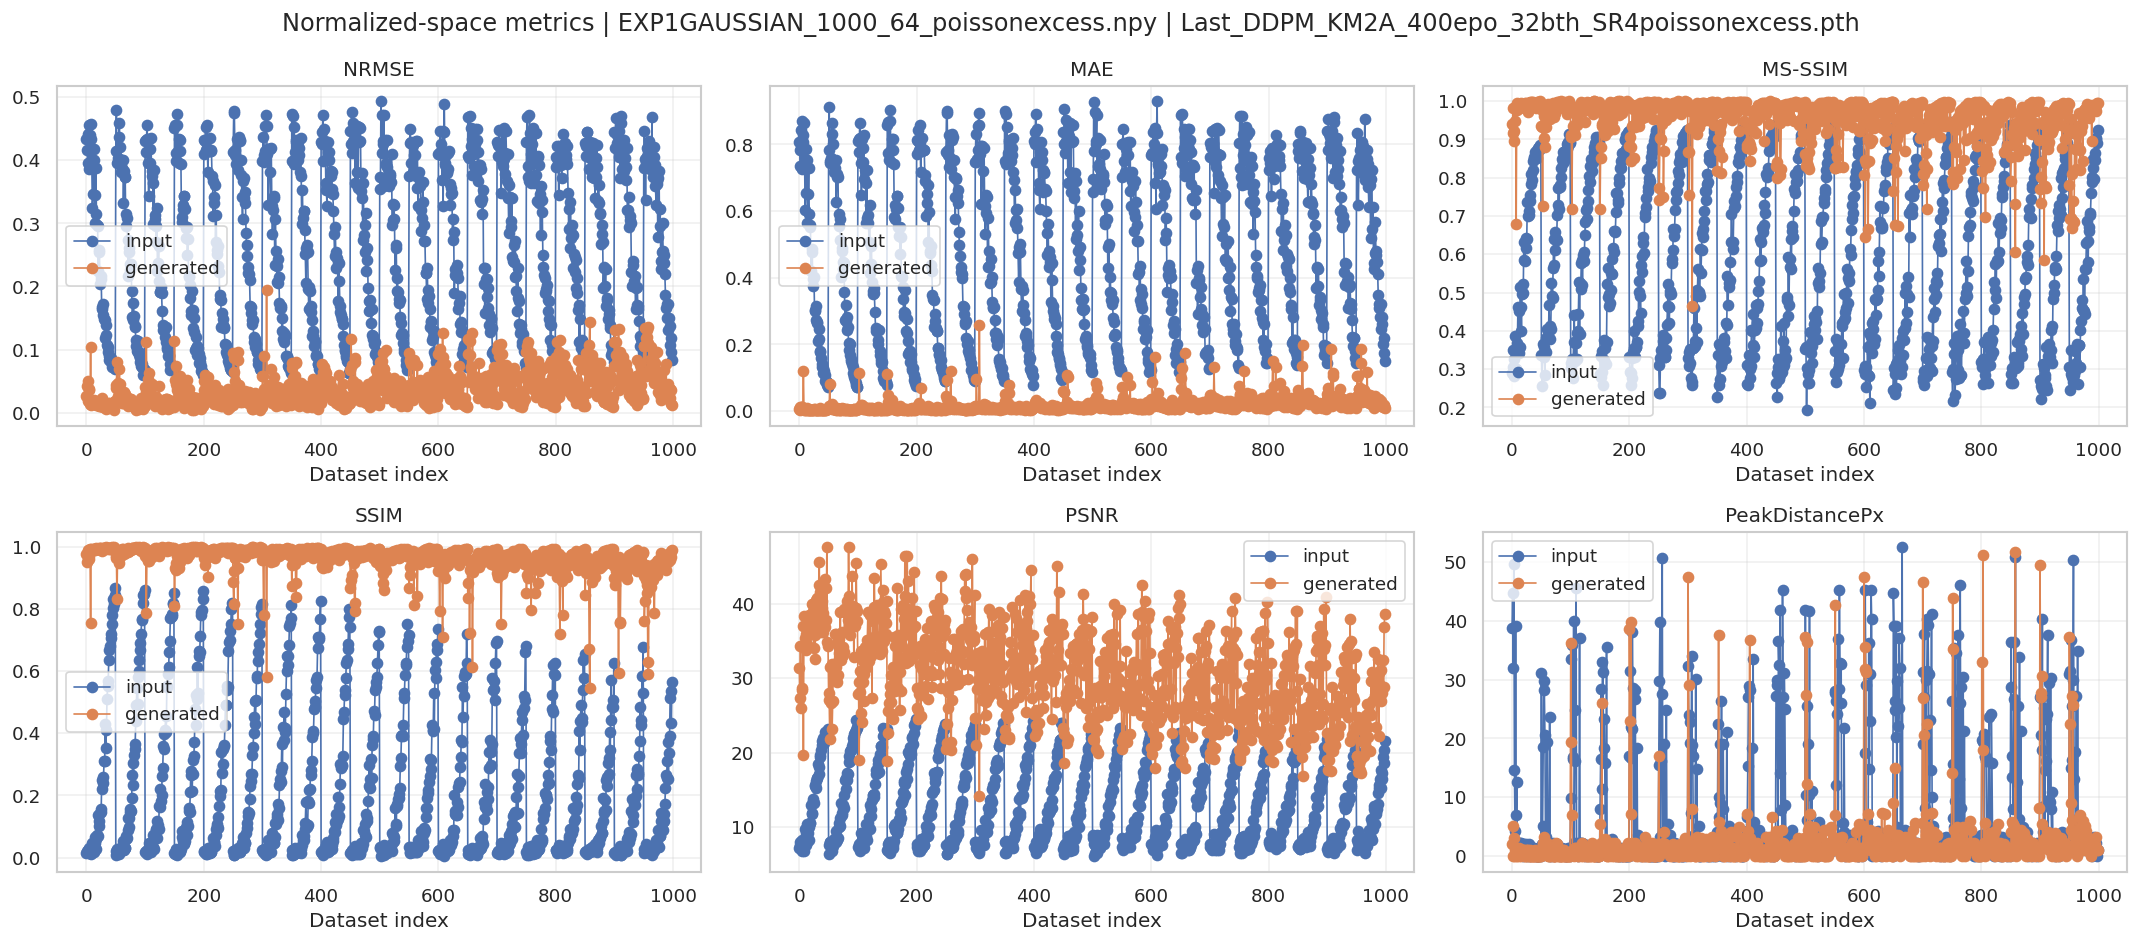

Saved metric plot: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/counts_metric_curves__EXP1GAUSSIAN_1000_64_poissonexcess__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


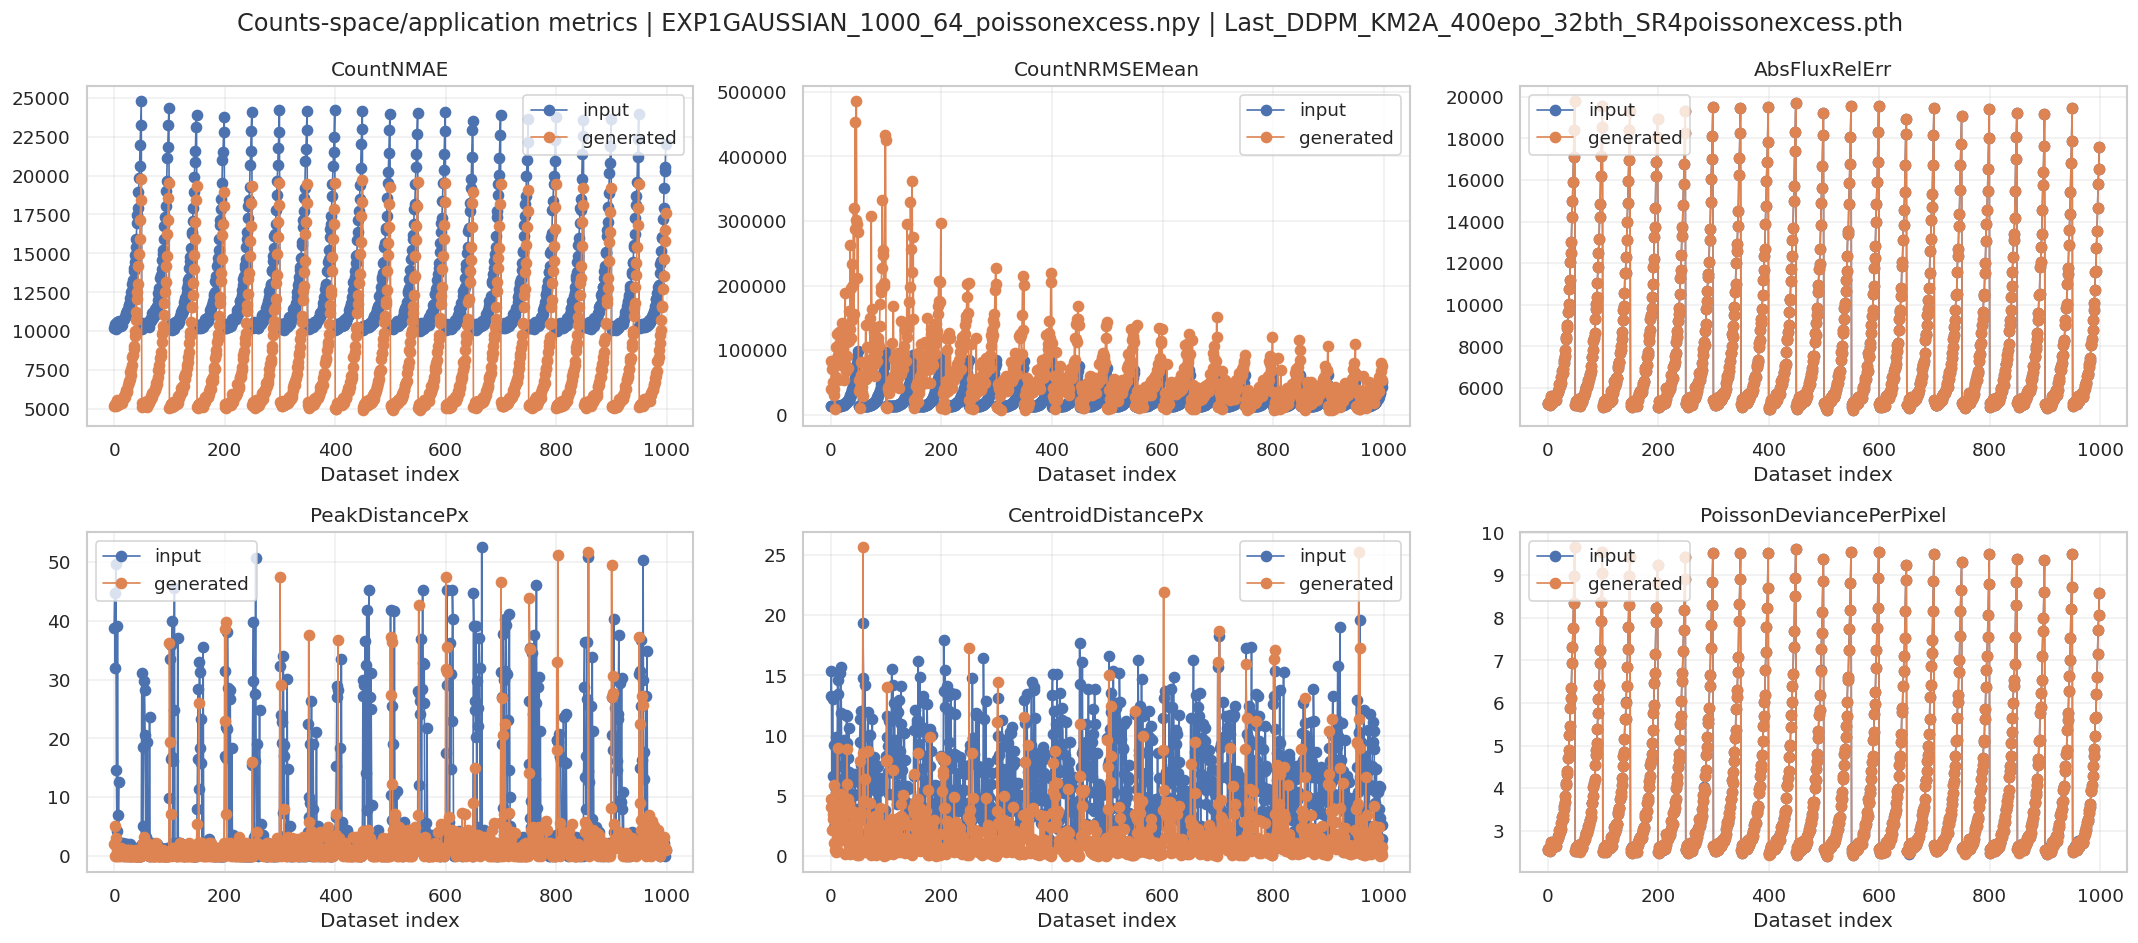

In [7]:
indices = select_eval_indices(
    total=inputs_np.shape[0],
    explicit=EVAL_INDICES,
    start=EVAL_START,
    stop=EVAL_STOP,
    step=EVAL_STEP,
)

normalized_rows, counts_rows, generated_cache = run_evaluations(indices)
normalized_summary = summarize_rows(normalized_rows)
counts_summary = summarize_rows(counts_rows)

print_normalized_summary(normalized_summary, n_images=len(indices))
print_counts_summary(counts_summary, n_images=len(indices))

if SAVE_OUTPUTS:
    save_evaluation_outputs(normalized_rows, counts_rows, normalized_summary, counts_summary, indices)

plot_metric_curves(
    normalized_rows,
    indices,
    metrics=["NRMSE", "MAE", "MS-SSIM", "SSIM", "PSNR", "PeakDistancePx"],
    title="Normalized-space metrics",
    filename_prefix="normalized_metric_curves",
)
plot_metric_curves(
    counts_rows,
    indices,
    metrics=["CountNMAE", "CountNRMSEMean", "AbsFluxRelErr", "PeakDistancePx", "CentroidDistancePx", "PoissonDeviancePerPixel"],
    title="Counts-space/application metrics",
    filename_prefix="counts_metric_curves",
)


In [8]:
def get_display_limits(image, floor_percentile=50, ceil_percentile=99.7):
    positive = image[image > 0]
    if positive.size == 0:
        return 0.0, 1.0
    vmin = float(np.percentile(positive, floor_percentile))
    vmax = float(np.percentile(positive, ceil_percentile))
    if vmax <= vmin:
        vmax = float(positive.max())
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax


def get_contour_levels(image, contour_percentiles=(70, 82, 90, 96)):
    positive = image[image > 0]
    if positive.size == 0:
        return []
    levels = np.percentile(positive, contour_percentiles)
    levels = np.unique(levels[levels > 0])
    if levels.size < 2:
        return []
    return levels


def imshow_enhanced(ax, image, title, cmap="turbo", gamma=0.55, contour=True):
    vmin, vmax = get_display_limits(image)
    im = ax.imshow(
        image,
        origin="lower",
        cmap=cmap,
        norm=PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax),
        interpolation="nearest",
    )
    if contour:
        levels = get_contour_levels(image)
        if len(levels) > 0:
            ax.contour(image, levels=levels, origin="lower", colors="#8fd3ff", linewidths=0.45, alpha=0.85)
    ax.set_title(title)
    ax.axis("off")
    return im


def imshow_plain(ax, image, title, cmap="hot"):
    im = ax.imshow(image, origin="lower", cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    return im


def image2d(array):
    return np.asarray(array).squeeze()


def auto_line_segment(target):
    h, w = target.shape
    y0, x0 = np.unravel_index(int(np.nanargmax(target)), target.shape)
    half = max(4, min(h, w) // 4)
    x1 = max(0, x0 - half)
    x2 = min(w - 1, x0 + half)
    y1 = y0
    y2 = y0
    return x1, y1, x2, y2


def line_profile(image, segment, samples=160):
    x1, y1, x2, y2 = segment
    xs = np.linspace(x1, x2, samples)
    ys = np.linspace(y1, y2, samples)
    return map_coordinates(image, [ys, xs], order=1, mode="nearest")


@torch.no_grad()
def generate_for_indices(vis_indices):
    vis_indices = np.asarray(vis_indices, dtype=int)
    result = {}
    for batch_start in range(0, len(vis_indices), INFERENCE_BATCH_SIZE):
        batch_indices = vis_indices[batch_start : batch_start + INFERENCE_BATCH_SIZE]
        missing = [int(i) for i in batch_indices if int(i) not in generated_cache]
        if missing:
            inputs = tensor_from_numpy_batch(inputs_np, missing)
            generated = generate_batch(inputs).detach().cpu().numpy()
            for image_index, generated_image in zip(missing, generated):
                generated_cache[int(image_index)] = generated_image
        for image_index in batch_indices:
            result[int(image_index)] = generated_cache[int(image_index)]
    return result


def counts_triplet(image_index):
    input_img = raw_input_counts([image_index])[0]
    target_img = raw_target_counts([image_index])[0]
    output_norm = generate_for_indices([image_index])[int(image_index)][None, ...]
    output_img = restore_generated_counts(output_norm, [image_index], COUNTS_RESTORE_MODE_FOR_VISUAL)[0]
    return image2d(input_img), image2d(output_img), image2d(target_img)


def visualize_indices(vis_indices, mode="enhanced", save_name=None):
    vis_indices = [int(i) for i in vis_indices]
    n = len(vis_indices)
    fig, axes = plt.subplots(n, 6, figsize=(21, 3.4 * n), squeeze=False)
    for row_i, image_index in enumerate(vis_indices):
        input_img, output_img, target_img = counts_triplet(image_index)
        segment = LINE_SEGMENTS.get(image_index, auto_line_segment(target_img))
        plotter = imshow_enhanced if mode == "enhanced" else imshow_plain
        plotter(axes[row_i, 0], input_img, f"#{image_index} input counts")
        plotter(axes[row_i, 1], output_img, "DDPM counts")
        plotter(axes[row_i, 2], target_img, "GT counts")

        profile_axes = []
        for ax in axes[row_i, :3]:
            x1, y1, x2, y2 = segment
            ax.plot([x1, x2], [y1, y2], linestyle="--", color="white", linewidth=1.4)
            axins = inset_axes(ax, width="26%", height="26%", loc=4)
            axins.axis("off")
            axins.patch.set_alpha(0)
            profile_axes.append(axins)
        for axins, image, color in zip(profile_axes, [input_img, output_img, target_img], ["red", "dodgerblue", "black"]):
            axins.plot(line_profile(image, segment), color=color, linewidth=1.0)

        res_input = input_img - target_img
        res_output = output_img - target_img
        vmax = np.nanmax(np.abs([res_input, res_output]))
        vmax = float(vmax if vmax > 0 else 1e-6)
        im3 = axes[row_i, 3].imshow(res_input, origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[row_i, 3].set_title("input - GT counts")
        axes[row_i, 3].axis("off")
        fig.colorbar(im3, ax=axes[row_i, 3], fraction=0.046, pad=0.04)
        im4 = axes[row_i, 4].imshow(res_output, origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[row_i, 4].set_title("output - GT counts")
        axes[row_i, 4].axis("off")
        fig.colorbar(im4, ax=axes[row_i, 4], fraction=0.046, pad=0.04)
        axes[row_i, 5].plot(line_profile(input_img, segment), color="red", label="input")
        axes[row_i, 5].plot(line_profile(output_img, segment), color="dodgerblue", label="output")
        axes[row_i, 5].plot(line_profile(target_img, segment), color="black", label="GT")
        axes[row_i, 5].set_title("counts line profile")
        axes[row_i, 5].legend(fontsize=8)
        axes[row_i, 5].grid(True, alpha=0.3)
    fig.suptitle(
        f"{mode} counts-space DDPM comparison | visual restore={COUNTS_RESTORE_MODE_FOR_VISUAL} | {DATA_NAME} | {MODEL_WEIGHT_NAME}",
        y=1.002,
    )
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        save_name = save_name or f"visual_{mode}_counts__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig_path = OUTPUT_DIR / save_name
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved visualization: {fig_path}")
    plt.show()


def show_channel_batch(kind="target", count=32, columns=8, random=True, seed=0, mode="enhanced"):
    rng = np.random.default_rng(seed)
    count = min(count, raw_inputs_np.shape[0])
    indices = np.sort(rng.choice(raw_inputs_np.shape[0], size=count, replace=False)) if random else np.arange(count)
    rows_count = math.ceil(len(indices) / columns)
    fig, axes = plt.subplots(rows_count, columns, figsize=(columns * 1.8, rows_count * 1.8), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, idx in zip(axes.ravel(), indices):
        if kind == "input":
            image = image2d(raw_input_counts([idx])[0])
        elif kind == "target":
            image = image2d(raw_target_counts([idx])[0])
        else:
            raise ValueError("kind must be 'input' or 'target'")
        if mode == "enhanced":
            imshow_enhanced(ax, image, f"#{idx}")
        else:
            imshow_plain(ax, image, f"#{idx}")
    fig.suptitle(f"{mode} counts batch view | {kind} | {DATA_NAME}", y=1.01)
    fig.tight_layout()
    plt.show()


/tmp/ipykernel_3399/3256862737.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved visualization: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/visual_plain_counts__EXP1GAUSSIAN_1000_64_poissonexcess__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


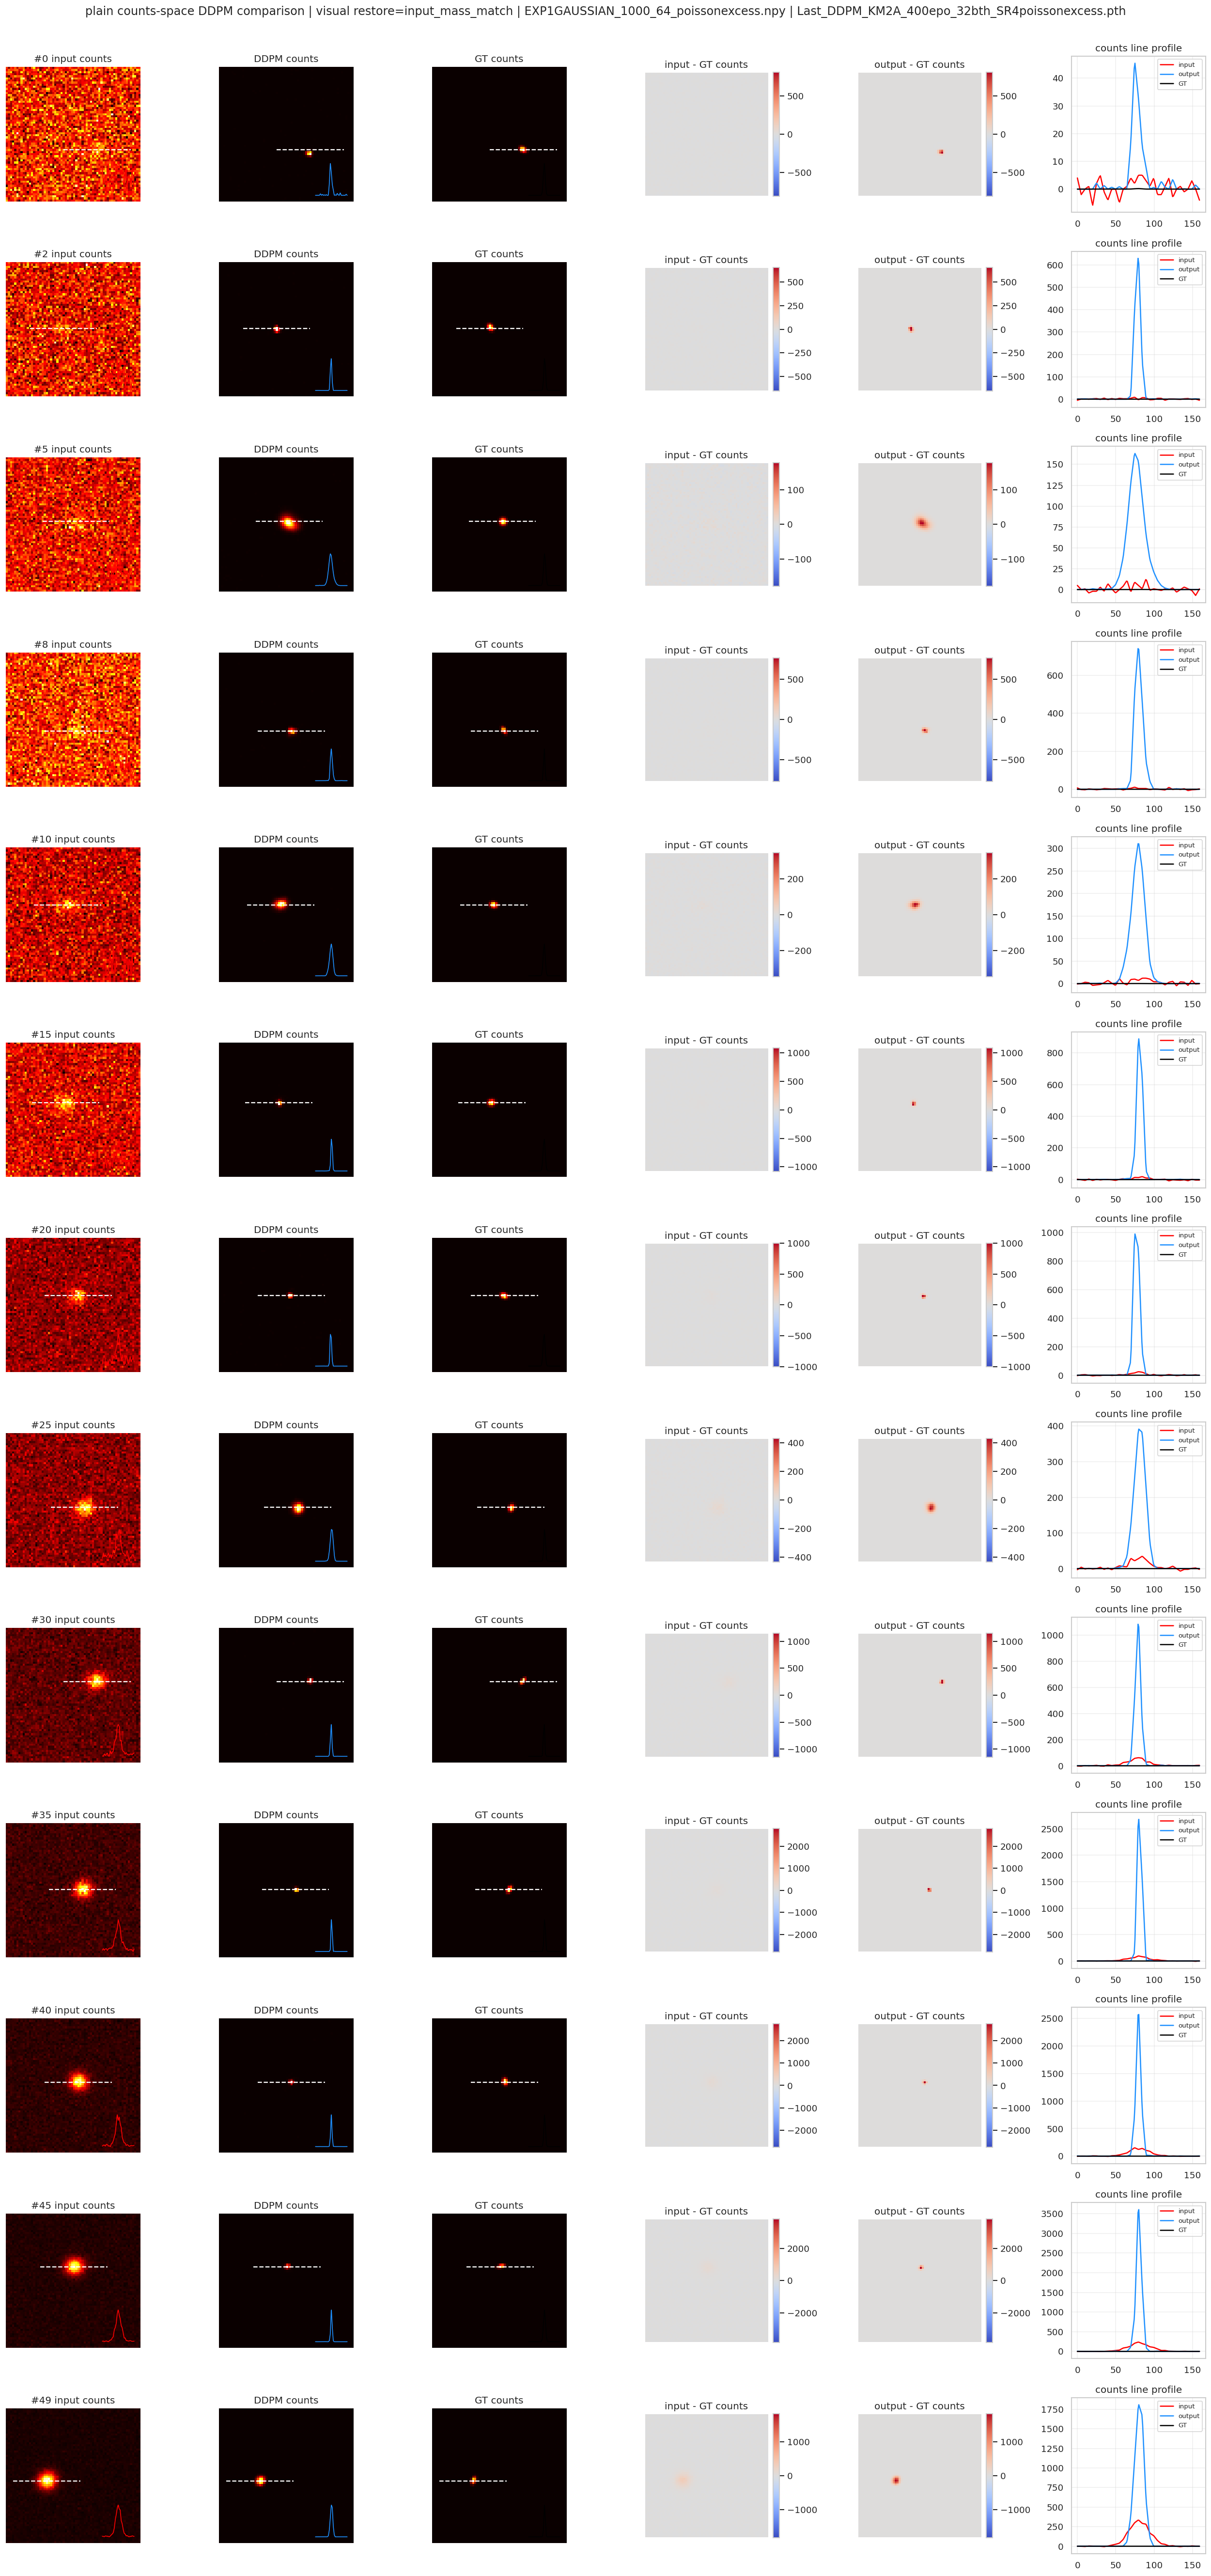

Saved visualization: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/visual_enhanced_counts__EXP1GAUSSIAN_1000_64_poissonexcess__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


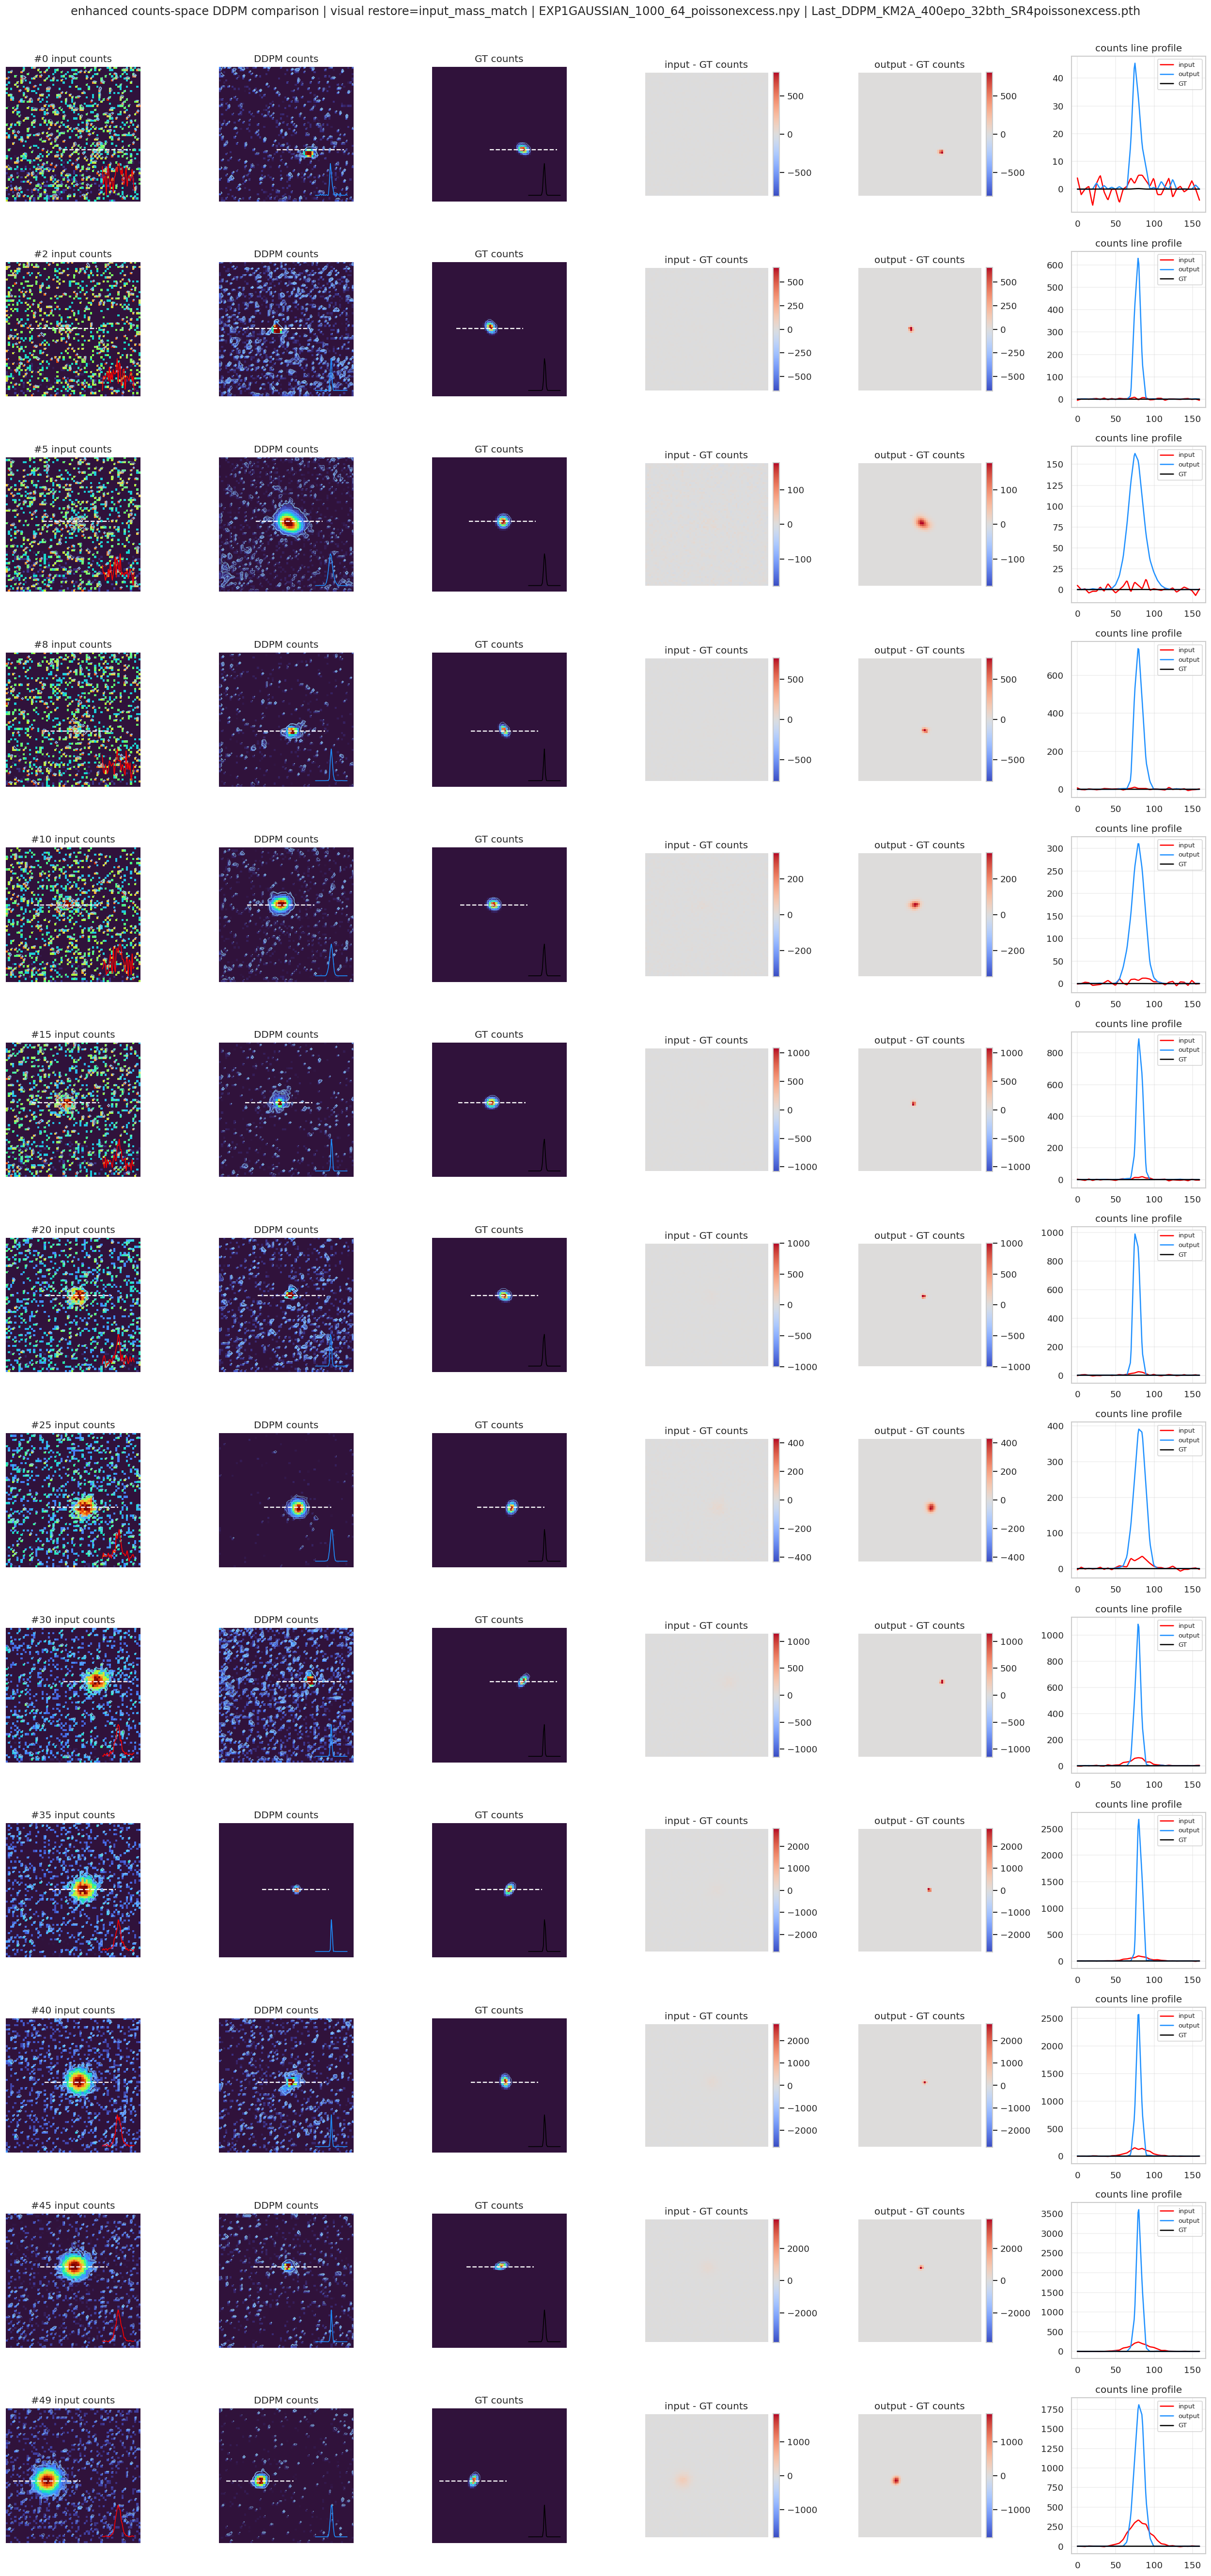

In [9]:
visualize_indices(VIS_INDICES, mode="plain")
visualize_indices(VIS_INDICES, mode="enhanced")


Saved summary bar plot: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/normalized_summary_bars__EXP1GAUSSIAN_1000_64_poissonexcess__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


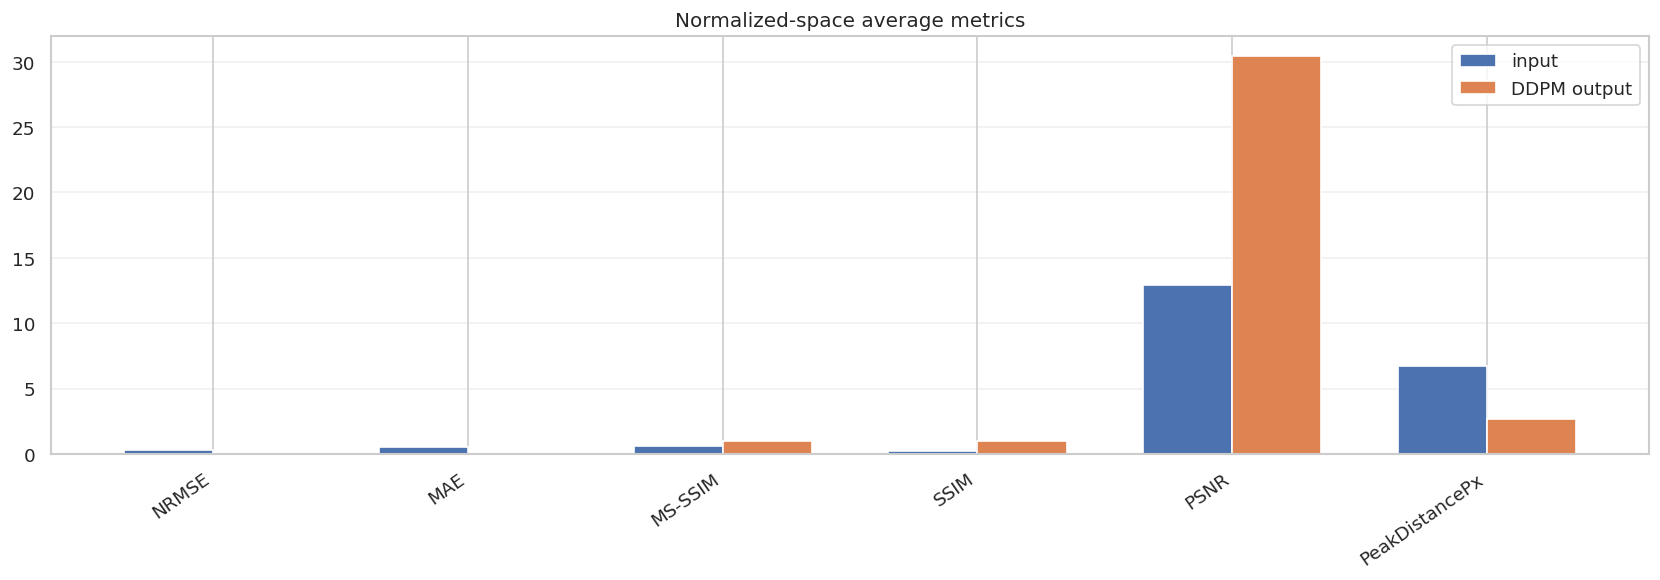

Saved summary bar plot: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/counts_summary_bars__EXP1GAUSSIAN_1000_64_poissonexcess__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


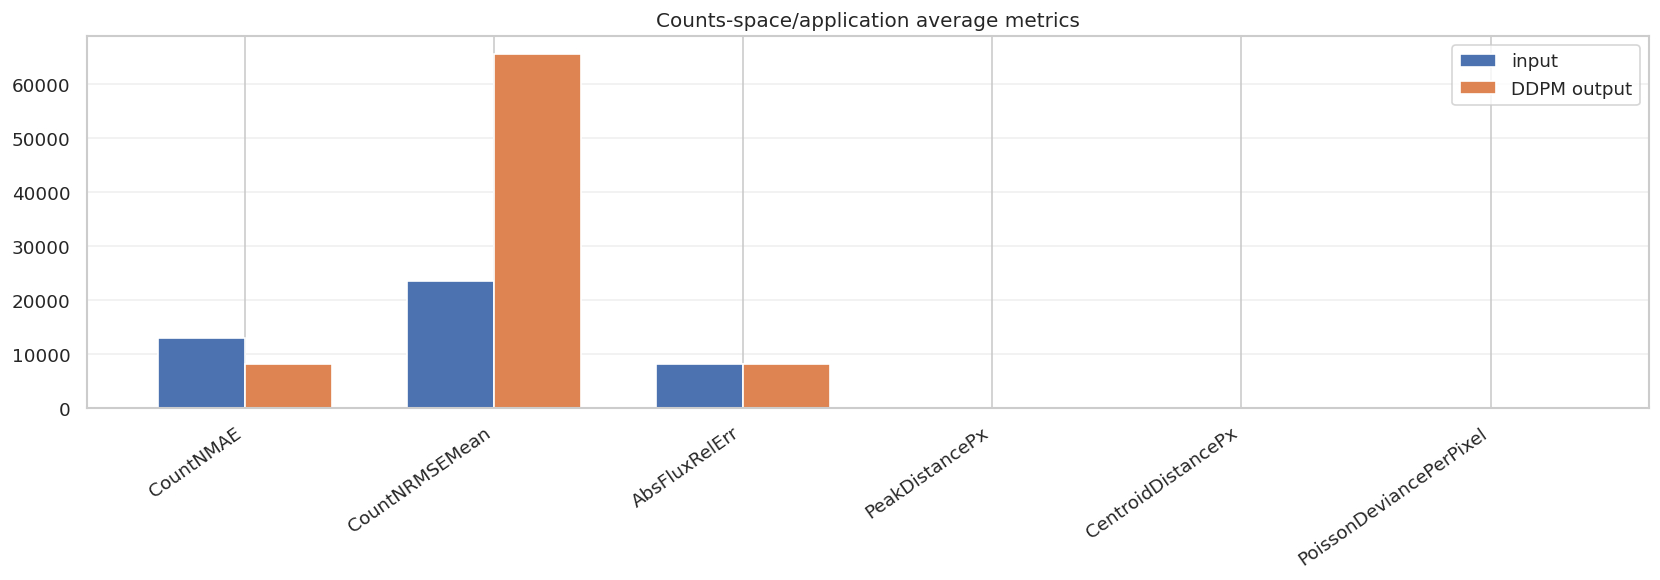

Saved residual histogram: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/counts_residual_hist__EXP1GAUSSIAN_1000_64_poissonexcess__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


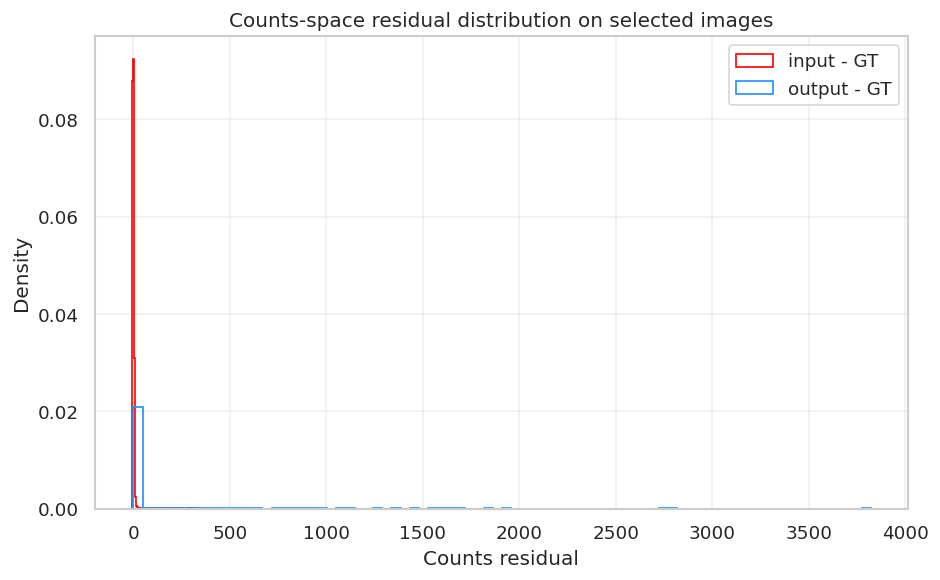

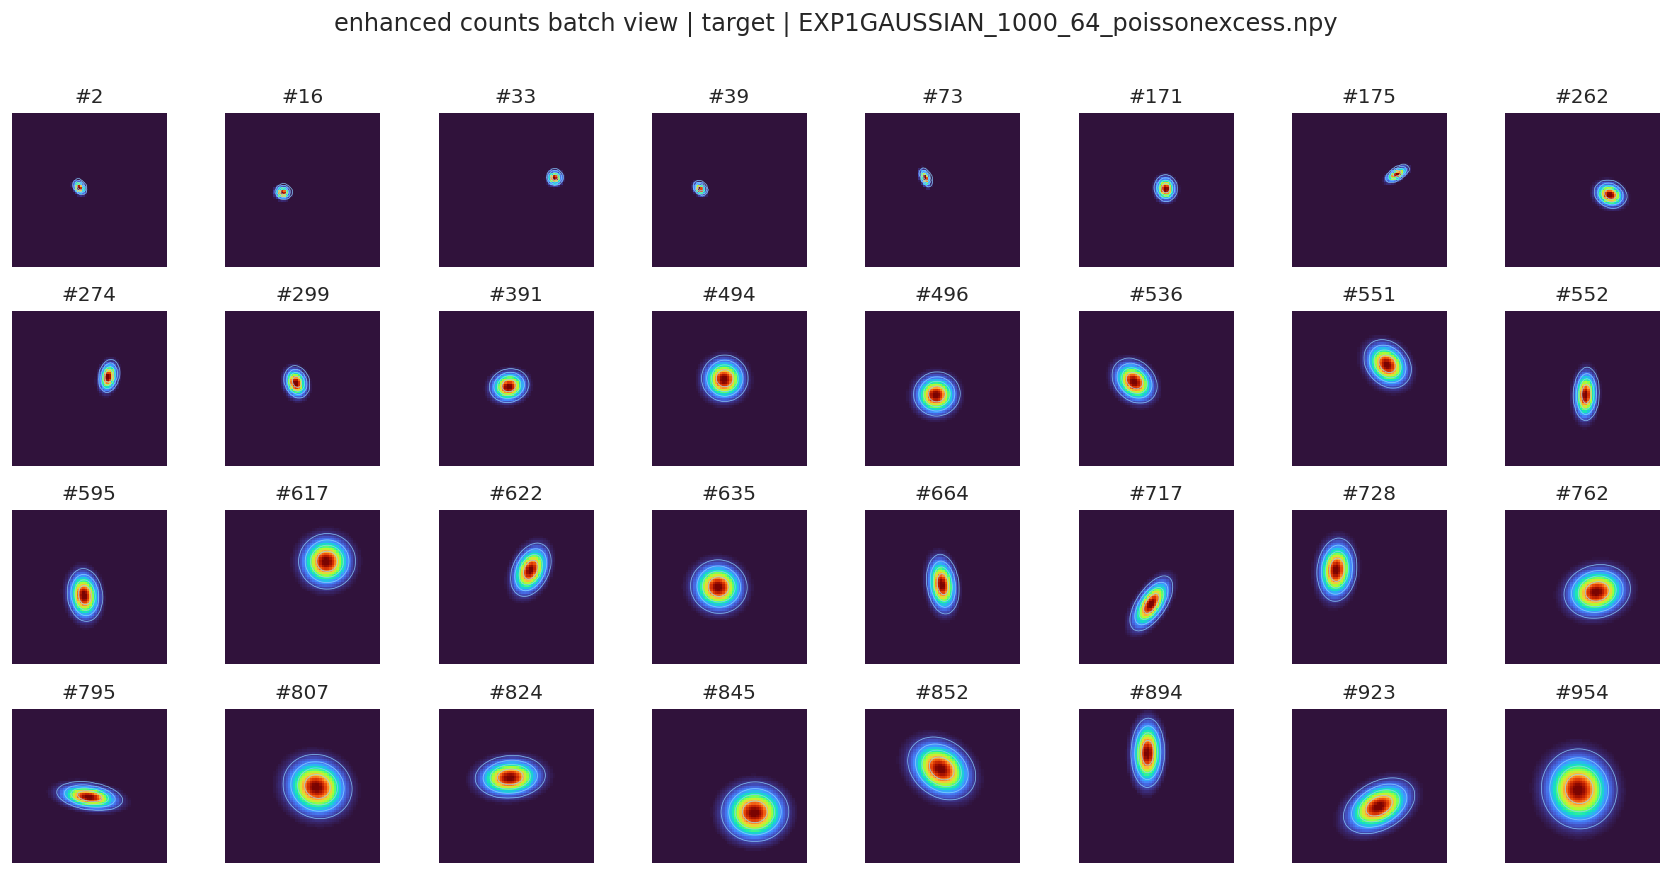

In [10]:
def plot_summary_bars(summary, metrics, title, filename_prefix):
    x = np.arange(len(metrics))
    width = 0.35
    input_means = [summary["input"][m]["mean"] for m in metrics]
    output_means = [summary["generated"][m]["mean"] for m in metrics]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width / 2, input_means, width, label="input")
    ax.bar(x + width / 2, output_means, width, label="DDPM output")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=35, ha="right")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"{filename_prefix}__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved summary bar plot: {fig_path}")
    plt.show()


def plot_counts_residual_histograms(vis_indices):
    input_residuals = []
    output_residuals = []
    for image_index in vis_indices:
        input_img, output_img, target_img = counts_triplet(int(image_index))
        input_residuals.append((input_img - target_img).reshape(-1))
        output_residuals.append((output_img - target_img).reshape(-1))
    input_residuals = np.concatenate(input_residuals)
    output_residuals = np.concatenate(output_residuals)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(input_residuals, bins=80, histtype="step", density=True, label="input - GT", color="red")
    ax.hist(output_residuals, bins=80, histtype="step", density=True, label="output - GT", color="dodgerblue")
    ax.set_title("Counts-space residual distribution on selected images")
    ax.set_xlabel("Counts residual")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"counts_residual_hist__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved residual histogram: {fig_path}")
    plt.show()


plot_summary_bars(
    normalized_summary,
    metrics=["NRMSE", "MAE", "MS-SSIM", "SSIM", "PSNR", "PeakDistancePx"],
    title="Normalized-space average metrics",
    filename_prefix="normalized_summary_bars",
)
plot_summary_bars(
    counts_summary,
    metrics=["CountNMAE", "CountNRMSEMean", "AbsFluxRelErr", "PeakDistancePx", "CentroidDistancePx", "PoissonDeviancePerPixel"],
    title="Counts-space/application average metrics",
    filename_prefix="counts_summary_bars",
)
plot_counts_residual_histograms(VIS_INDICES)
show_channel_batch(kind="target", count=32, columns=8, random=True, seed=SAMPLING_SEED, mode="enhanced")


## Attach Exp1 construction metadata

Join `flux_F0`, `r39`, `Cx`, `Cy`, ROI from `exp1_parameters.json` onto the per-image
counts metrics so the POINT confidence/quality can be analysed against physical parameters.

In [11]:
exp1_meta = json.loads(EXP1_PARAM_JSON.read_text(encoding='utf-8'))
exp1_samples = exp1_meta['samples'][EXP1_SOURCE_TYPE]

by_index = {row['image_index']: row for row in counts_rows if row['source'] == 'generated'}
joined = []
for image_index in indices:
    image_index = int(image_index)
    sample = exp1_samples[image_index]
    row = dict(by_index.get(image_index, {'image_index': image_index, 'source': 'generated'}))
    row['flux_F0'] = sample.get('flux_F0', sample.get('response_F0'))
    row['scale_r39_deg'] = sample.get('scale_r39_deg')
    row['Cx_deg'] = sample.get('Cx_deg')
    row['Cy_deg'] = sample.get('Cy_deg')
    row['roi_ra_center_deg'] = sample.get('roi_ra_center_deg')
    row['roi_dec_center_deg'] = sample.get('roi_dec_center_deg')
    joined.append(row)

exp1_csv = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_metrics_with_meta.csv'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if joined:
    with exp1_csv.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(joined[0].keys()))
        writer.writeheader()
        writer.writerows(joined)
    print(f'Saved Exp1 joined metrics: {exp1_csv}')
else:
    print('No counts rows available to join Exp1 metadata.')


Saved Exp1 joined metrics: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_metrics_with_meta.csv


## Step 3 — Extract GT and reconstructed GAUSSIAN morphology

Use one shared image-measurement function on both GT and DDPM SR maps:
- `(Cx, Cy)` from positive-weighted first moments
- `sigma_major`, `sigma_minor`, `epsilon` from positive-weighted covariance eigen-decomposition
- `position_angle_deg` from the major-axis eigenvector

Calling the same function on the rasterized GT image captures the 0.1 deg/pixel
sampling systematic relative to the construction-truth metadata.

In [27]:
# Coordinate axes shared by every image-measurement call below.
PIXEL_SIZE_DEG = 0.1
FOV_DEG = image_size * PIXEL_SIZE_DEG
PSF39_DEG = 0.223607
PSF68_DEG = 0.412311
PSF90_DEG = 0.583095
CENTER_THRESHOLD_DEG = 1.0 * PSF68_DEG       # GAUSSIAN center correctness threshold
EXTENT_THRESHOLD_DEG = 1.0 * PSF68_DEG       # GAUSSIAN sigma_major correctness threshold
EPSILON_THRESHOLD = 0.30                     # GAUSSIAN eccentricity correctness threshold

image_axis_deg = (np.arange(image_size, dtype=np.float64) - (image_size - 1) / 2.0) * PIXEL_SIZE_DEG
X_DEG_GRID, Y_DEG_GRID = np.meshgrid(image_axis_deg, image_axis_deg)


def positive_image(image):
    return np.clip(np.asarray(image, dtype=np.float64), 0.0, None)


def estimate_gaussian_params(image):
    """Return dict with Cx, Cy, sigma_major, sigma_minor, epsilon, position_angle_deg, ok."""
    arr = positive_image(image)
    total = arr.sum()
    if not np.isfinite(total) or total <= 0:
        return dict(Cx=np.nan, Cy=np.nan, sigma_major=np.nan, sigma_minor=np.nan,
                    epsilon=np.nan, position_angle_deg=np.nan, ok=False)
    cx = float((arr * X_DEG_GRID).sum() / total)
    cy = float((arr * Y_DEG_GRID).sum() / total)
    dx = X_DEG_GRID - cx
    dy = Y_DEG_GRID - cy
    cov = np.array([
        [float((arr * dx * dx).sum() / total), float((arr * dx * dy).sum() / total)],
        [float((arr * dx * dy).sum() / total), float((arr * dy * dy).sum() / total)],
    ])
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0.0)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vec = vecs[:, order[0]]
    sigma_major = float(np.sqrt(vals[0]))
    sigma_minor = float(np.sqrt(vals[1]))
    epsilon = float(1.0 - sigma_minor / sigma_major) if sigma_major > 0 else np.nan
    angle = float(np.degrees(np.arctan2(vec[1], vec[0])) % 180.0)
    return dict(Cx=cx, Cy=cy, sigma_major=sigma_major, sigma_minor=sigma_minor,
                epsilon=epsilon, position_angle_deg=angle, ok=True)


print('PSF68_DEG =', PSF68_DEG)
print('Center threshold = 0.3 PSF68 =', CENTER_THRESHOLD_DEG, 'deg')
print('Sigma major threshold = 0.3 PSF68 =', EXTENT_THRESHOLD_DEG, 'deg')
print('Epsilon threshold =', EPSILON_THRESHOLD)


PSF68_DEG = 0.412311
Center threshold = 0.3 PSF68 = 0.412311 deg
Sigma major threshold = 0.3 PSF68 = 0.412311 deg
Epsilon threshold = 0.3


In [28]:
# Build per-sample arrays of GT/SR centers and extents using the SAME estimator.
indices_arr = np.asarray(indices, dtype=int)
n_eval = int(indices_arr.shape[0])

meta_cx = np.array([exp1_samples[int(i)].get('Cx_deg', np.nan) for i in indices_arr], dtype=np.float64)
meta_cy = np.array([exp1_samples[int(i)].get('Cy_deg', np.nan) for i in indices_arr], dtype=np.float64)
meta_r39 = np.array([exp1_samples[int(i)].get('scale_r39_deg', np.nan) for i in indices_arr], dtype=np.float64)
flux_arr = np.array([exp1_samples[int(i)].get('flux_F0', exp1_samples[int(i)].get('response_F0', np.nan)) for i in indices_arr], dtype=np.float64)
meta_morph = [exp1_samples[int(i)].get('morphology_parameters', {}) for i in indices_arr]
meta_sigma_major = np.array([m.get('sigma_major_deg', np.nan) for m in meta_morph], dtype=np.float64)
meta_epsilon = np.array([m.get('epsilon', np.nan) for m in meta_morph], dtype=np.float64)

# GT and SR counts maps (same restoration as the rest of the notebook).
gt_counts = raw_target_counts(indices_arr)
sr_counts_norm = np.stack([generate_for_indices([int(i)])[int(i)] for i in indices_arr], axis=0)
sr_counts = restore_generated_counts(sr_counts_norm, indices_arr, COUNTS_RESTORE_MODE_FOR_METRICS)

gt_records = [estimate_gaussian_params(gt_counts[k].squeeze()) for k in range(n_eval)]
sr_records = [estimate_gaussian_params(sr_counts[k].squeeze()) for k in range(n_eval)]

def col(records, key):
    return np.array([r.get(key, np.nan) for r in records], dtype=np.float64)

gt_cx = col(gt_records, 'Cx')
gt_cy = col(gt_records, 'Cy')
gt_sigma_major = col(gt_records, 'sigma_major')
gt_sigma_minor = col(gt_records, 'sigma_minor')
gt_epsilon = col(gt_records, 'epsilon')
gt_pa = col(gt_records, 'position_angle_deg')
gt_detected = np.array([bool(r['ok']) for r in gt_records])

sr_cx = col(sr_records, 'Cx')
sr_cy = col(sr_records, 'Cy')
sr_sigma_major = col(sr_records, 'sigma_major')
sr_sigma_minor = col(sr_records, 'sigma_minor')
sr_epsilon = col(sr_records, 'epsilon')
sr_pa = col(sr_records, 'position_angle_deg')
sr_detected = np.array([bool(r['ok']) for r in sr_records])

grid_systematic_deg = np.hypot(gt_cx - meta_cx, gt_cy - meta_cy)
sigma_grid_systematic_deg = np.abs(gt_sigma_major - meta_sigma_major)
print('center grid sys median/max [deg] =', float(np.nanmedian(grid_systematic_deg)), float(np.nanmax(grid_systematic_deg)))
print('sigma_major grid sys median/max [deg] =', float(np.nanmedian(sigma_grid_systematic_deg)), float(np.nanmax(sigma_grid_systematic_deg)))


center grid sys median/max [deg] = 0.01915789854474421 0.03413707011889977
sigma_major grid sys median/max [deg] = 0.001071347877229123 0.0030608864290838783


## Step 4 — Compute GAUSSIAN correctness metrics

Per-sample columns:
- `center_error_deg` = ||SR center - GT image center||
- `sigma_major_error_deg` = |SR sigma_major - GT sigma_major|
- `epsilon_error` = |SR epsilon - GT epsilon|
- `grid_systematic_deg`, `sigma_grid_systematic_deg`: rasterization systematics from metadata vs GT image
- `total_center_error_with_grid_deg`, `total_sigma_error_with_grid_deg`: quadrature-combined error bars
- `correct = detected AND center within 0.3 PSF68 AND sigma_major within 0.3 PSF68 AND |Δε| < 0.30`

In [30]:
import pandas as pd

center_error_deg = np.hypot(sr_cx - gt_cx, sr_cy - gt_cy)
center_error_vs_meta_deg = np.hypot(sr_cx - meta_cx, sr_cy - meta_cy)
sigma_major_error_deg = np.abs(sr_sigma_major - gt_sigma_major)
sigma_major_error_vs_meta_deg = np.abs(sr_sigma_major - meta_sigma_major)
epsilon_error = np.abs(sr_epsilon - gt_epsilon)
epsilon_error_vs_meta = np.abs(sr_epsilon - meta_epsilon)

total_center_error_with_grid_deg = np.sqrt(center_error_deg ** 2 + grid_systematic_deg ** 2)
total_sigma_error_with_grid_deg = np.sqrt(sigma_major_error_deg ** 2 + sigma_grid_systematic_deg ** 2)

detected_mask = gt_detected & sr_detected
center_correct = detected_mask & (center_error_deg < CENTER_THRESHOLD_DEG)
sigma_correct = detected_mask & (sigma_major_error_deg < EXTENT_THRESHOLD_DEG)
epsilon_correct = detected_mask & (epsilon_error < EPSILON_THRESHOLD)
correct_mask = center_correct & sigma_correct & epsilon_correct

morphology = pd.DataFrame({
    'image_index': indices_arr.astype(int),
    'flux_F0': flux_arr,
    'scale_r39_deg': meta_r39,
    'Cx_meta_deg': meta_cx,
    'Cy_meta_deg': meta_cy,
    'sigma_major_meta_deg': meta_sigma_major,
    'epsilon_meta': meta_epsilon,
    'Cx_gt_image_deg': gt_cx,
    'Cy_gt_image_deg': gt_cy,
    'sigma_major_gt_deg': gt_sigma_major,
    'sigma_minor_gt_deg': gt_sigma_minor,
    'epsilon_gt': gt_epsilon,
    'position_angle_gt_deg': gt_pa,
    'Cx_sr_deg': sr_cx,
    'Cy_sr_deg': sr_cy,
    'sigma_major_sr_deg': sr_sigma_major,
    'sigma_minor_sr_deg': sr_sigma_minor,
    'epsilon_sr': sr_epsilon,
    'position_angle_sr_deg': sr_pa,
    'gt_detected': gt_detected,
    'sr_detected': sr_detected,
    'detected': detected_mask,
    'center_error_deg': center_error_deg,
    'center_error_vs_meta_deg': center_error_vs_meta_deg,
    'sigma_major_error_deg': sigma_major_error_deg,
    'sigma_major_error_vs_meta_deg': sigma_major_error_vs_meta_deg,
    'epsilon_error': epsilon_error,
    'epsilon_error_vs_meta': epsilon_error_vs_meta,
    'grid_systematic_deg': grid_systematic_deg,
    'sigma_grid_systematic_deg': sigma_grid_systematic_deg,
    'total_center_error_with_grid_deg': total_center_error_with_grid_deg,
    'total_sigma_error_with_grid_deg': total_sigma_error_with_grid_deg,
    'center_threshold_deg': CENTER_THRESHOLD_DEG,
    'extent_threshold_deg': EXTENT_THRESHOLD_DEG,
    'epsilon_threshold': EPSILON_THRESHOLD,
    'center_correct': center_correct,
    'sigma_correct': sigma_correct,
    'epsilon_correct': epsilon_correct,
    'correct': correct_mask,
})

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
morph_csv = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_morphology_per_sample.csv'
morphology.to_csv(morph_csv, index=False)
print(f'Saved per-sample morphology metrics: {morph_csv}')
morphology.head()


Saved per-sample morphology metrics: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_morphology_per_sample.csv


,image_index,flux_F0,scale_r39_deg,Cx_meta_deg,Cy_meta_deg,sigma_major_meta_deg,epsilon_meta,Cx_gt_image_deg,Cy_gt_image_deg,sigma_major_gt_deg,...,sigma_grid_systematic_deg,total_center_error_with_grid_deg,total_sigma_error_with_grid_deg,center_threshold_deg,extent_threshold_deg,epsilon_threshold,center_correct,sigma_correct,epsilon_correct,correct
0,0,0.100000,0.1,1.135705,-0.711377,0.100575,0.312934,1.125,-0.725000,0.103636,...,0.003061,0.408661,1.209435,0.412311,0.412311,0.3,True,False,True,False
1,1,0.109854,0.1,1.546675,0.589482,0.100575,0.244927,1.525,0.575000,0.103636,...,0.003061,0.474639,0.755170,0.412311,0.412311,0.3,False,False,True,False
2,2,0.120679,0.1,-0.432821,0.067749,0.100575,0.291590,-0.425,0.075000,0.103636,...,0.003061,0.215726,1.136437,0.412311,0.412311,0.3,True,False,True,False
3,3,0.132571,0.1,-1.271088,-0.315565,0.100575,0.374869,-1.275,-0.325009,0.103636,...,0.003061,0.351898,0.334254,0.412311,0.412311,0.3,True,True,True,True
4,4,0.145635,0.1,0.497387,0.504736,0.100575,0.588670,0.475,0.526409,0.103636,...,0.003060,0.307334,0.692477,0.412311,0.412311,0.3,True,False,False,False


## Step 5 — Aggregate over flux × r39 and plot 2D confidence map

GAUSSIAN has both flux and scale (`r39`), so the confidence phase diagram is 2D.
For each (flux_F0, r39) bin we compute:
- detection_rate, correct_rate (and sub-rates for center/sigma/epsilon) with binomial std
- median center error, sigma_major error, epsilon error, plus their grid systematic medians

Reconstruction confidence = correct_count / total_count per (flux, r39) bin.
Region with confidence >= 0.95 is reconstructable at 95% confidence.

In [31]:
def binomial_std(p, n):
    if n <= 0 or not np.isfinite(p):
        return np.nan
    return float(np.sqrt(max(p, 0.0) * max(1.0 - p, 0.0) / n))

agg = morphology.groupby(['scale_r39_deg', 'flux_F0']).agg(
    n_total=('image_index', 'count'),
    n_detected=('detected', 'sum'),
    n_center_correct=('center_correct', 'sum'),
    n_sigma_correct=('sigma_correct', 'sum'),
    n_epsilon_correct=('epsilon_correct', 'sum'),
    n_correct=('correct', 'sum'),
    median_center_error_deg=('center_error_deg', 'median'),
    median_sigma_error_deg=('sigma_major_error_deg', 'median'),
    median_epsilon_error=('epsilon_error', 'median'),
    median_grid_systematic_deg=('grid_systematic_deg', 'median'),
    median_sigma_grid_systematic_deg=('sigma_grid_systematic_deg', 'median'),
).reset_index().sort_values(['scale_r39_deg', 'flux_F0']).reset_index(drop=True)

n_total_safe = agg['n_total'].clip(lower=1)
agg['detection_rate'] = agg['n_detected'] / n_total_safe
agg['center_correct_rate'] = agg['n_center_correct'] / n_total_safe
agg['sigma_correct_rate'] = agg['n_sigma_correct'] / n_total_safe
agg['epsilon_correct_rate'] = agg['n_epsilon_correct'] / n_total_safe
agg['correct_rate'] = agg['n_correct'] / n_total_safe
agg['detection_rate_err'] = [binomial_std(p, n) for p, n in zip(agg['detection_rate'], agg['n_total'])]
agg['correct_rate_err'] = [binomial_std(p, n) for p, n in zip(agg['correct_rate'], agg['n_total'])]

agg_csv = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_confidence_by_flux_r39.csv'
agg.to_csv(agg_csv, index=False)
print(f'Saved flux × r39 aggregated confidence: {agg_csv}')
agg.head()


Saved flux × r39 aggregated confidence: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_confidence_by_flux_r39.csv


,scale_r39_deg,flux_F0,n_total,n_detected,n_center_correct,n_sigma_correct,n_epsilon_correct,n_correct,median_center_error_deg,median_sigma_error_deg,median_epsilon_error,median_grid_systematic_deg,median_sigma_grid_systematic_deg,detection_rate,center_correct_rate,sigma_correct_rate,epsilon_correct_rate,correct_rate,detection_rate_err,correct_rate_err
0,0.1,0.100000,1,1,1,0,1,0,0.408294,1.209431,0.090702,0.017326,0.003061,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.1,0.109854,1,1,0,0,1,0,0.473922,0.755163,0.199725,0.026068,0.003061,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.1,0.120679,1,1,1,0,1,0,0.215462,1.136433,0.255634,0.010665,0.003061,1.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.1,0.132571,1,1,1,1,1,1,0.351750,0.334240,0.283532,0.010222,0.003061,1.0,1.0,1.0,1.0,1.0,0.0,0.0
4,0.1,0.145635,1,1,1,0,0,0,0.305750,0.692471,0.471634,0.031160,0.003060,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [1]:
from matplotlib.colors import LogNorm

def pivot_metric(df, metric):
    return df.pivot(index='scale_r39_deg', columns='flux_F0', values=metric).sort_index()

pivot_correct = pivot_metric(agg, 'correct_rate')
pivot_detect = pivot_metric(agg, 'detection_rate')
pivot_center = pivot_metric(agg, 'median_center_error_deg')
pivot_sigma = pivot_metric(agg, 'median_sigma_error_deg')

flux_values = pivot_correct.columns.to_numpy()
r39_values = pivot_correct.index.to_numpy()


def plot_phase(ax, pivot, title, vmin=0.0, vmax=1.0, cmap='viridis', log_color=False):
    data = pivot.values
    if log_color:
        norm = LogNorm(vmin=max(np.nanmin(data[data > 0]), 1e-4), vmax=max(np.nanmax(data), 1e-3))
        im = ax.pcolormesh(flux_values, r39_values, data, cmap=cmap, norm=norm, shading='auto')
    else:
        im = ax.pcolormesh(flux_values, r39_values, data, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    ax.set_xscale('log')
    ax.set_xlabel('F0 coefficient [\u00d71e-16]')
    ax.set_ylabel('r39 [deg]')
    ax.set_title(title)
    return im


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
im0 = plot_phase(axes[0, 0], pivot_correct, f'{EXP1_SOURCE_TYPE} correct rate', vmin=0, vmax=1)
fig.colorbar(im0, ax=axes[0, 0], label='correct rate')
try:
    cs = axes[0, 0].contour(flux_values, r39_values, pivot_correct.values, levels=[0.95], colors='red', linewidths=1.4)
    axes[0, 0].clabel(cs, fmt='95%')
except Exception as exc:
    print('contour skipped:', exc)

im1 = plot_phase(axes[0, 1], pivot_detect, f'{EXP1_SOURCE_TYPE} detection rate', vmin=0, vmax=1)
fig.colorbar(im1, ax=axes[0, 1], label='detection rate')

im2 = plot_phase(axes[1, 0], pivot_center, f'{EXP1_SOURCE_TYPE} median center error [deg]', cmap='magma', log_color=True)
fig.colorbar(im2, ax=axes[1, 0], label='deg')

im3 = plot_phase(axes[1, 1], pivot_sigma, f'{EXP1_SOURCE_TYPE} median |Δsigma_major| [deg]', cmap='magma', log_color=True)
fig.colorbar(im3, ax=axes[1, 1], label='deg')

fig.suptitle(f'Exp1 {EXP1_SOURCE_TYPE} confidence phase map | {DATA_NAME} | {MODEL_WEIGHT_NAME}')
fig.tight_layout()
phase_path = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_confidence_phase_map.png'
fig.savefig(phase_path, dpi=300, bbox_inches='tight')
print(f'Saved phase map: {phase_path}')
plt.show()


NameError: name 'agg' is not defined

Saved per-r39 correct-rate curves: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_correct_rate_curves.png


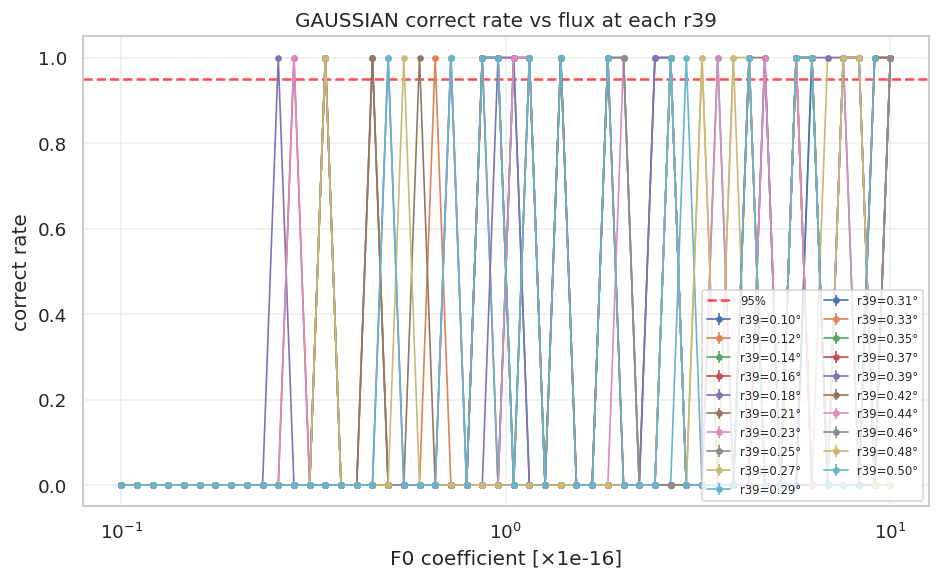

Saved 95% flux thresholds per r39: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_95pct_flux_threshold_by_r39.csv


,scale_r39_deg,flux_threshold_95pct
0,0.100000,2.682696
1,0.121053,10.000000
2,0.142105,0.339322
3,0.163158,0.868511
4,0.184211,0.339322
5,0.205263,0.868511
6,0.226316,2.682696
7,0.247368,0.339322
8,0.268421,0.339322
9,0.289474,0.868511


In [17]:
# Per-r39 confidence curves vs flux, with 95% line.
fig, ax = plt.subplots(figsize=(8, 5))
for r39_val, group in agg.groupby('scale_r39_deg'):
    g = group.sort_values('flux_F0')
    ax.errorbar(g['flux_F0'], g['correct_rate'], yerr=g['correct_rate_err'],
                marker='.', linewidth=1, label=f'r39={r39_val:.2f}\u00b0')
ax.axhline(0.95, linestyle='--', color='red', alpha=0.7, label='95%')
ax.set_xscale('log')
ax.set_xlabel('F0 coefficient [\u00d71e-16]')
ax.set_ylabel('correct rate')
ax.set_ylim(-0.05, 1.05)
ax.set_title(f'{EXP1_SOURCE_TYPE} correct rate vs flux at each r39')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='lower right')
fig.tight_layout()
curve_path = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_correct_rate_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
print(f'Saved per-r39 correct-rate curves: {curve_path}')
plt.show()

# Smallest flux that achieves >=95% confidence at each r39.
thresholds = []
for r39_val, group in agg.groupby('scale_r39_deg'):
    g = group.sort_values('flux_F0')
    above = g[g['correct_rate'] >= 0.95]
    flux_thr = float(above['flux_F0'].min()) if not above.empty else float('nan')
    thresholds.append({'scale_r39_deg': float(r39_val), 'flux_threshold_95pct': flux_thr})
thresholds = pd.DataFrame(thresholds).sort_values('scale_r39_deg').reset_index(drop=True)
thresholds_csv = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_95pct_flux_threshold_by_r39.csv'
thresholds.to_csv(thresholds_csv, index=False)
print(f'Saved 95% flux thresholds per r39: {thresholds_csv}')
thresholds


## Step 6 — PoissonDeviancePerPixel-only confidence (counts space)

The morphology metrics from Step 4-5 are strict and can produce noisy 2D phase
maps for GAUSSIAN. As an alternative, define `correct` purely from the existing
counts-space `PoissonDeviancePerPixel` already computed by `run_evaluations()`:

- This is the same metric and same restoration as the curves produced by
  `plot_metric_curves(counts_rows, ..., metrics=[..., 'PoissonDeviancePerPixel'])`,
  so the evaluation environment is unchanged.
- A sample is considered correctly reconstructed if
  `PoissonDeviancePerPixel <= POISSON_DEVIANCE_THRESHOLD`.
  Lower deviance means the DDPM counts map is closer to GT counts under the
  Poisson-likelihood discrepancy, so smaller is better.
- The threshold defaults to 3.0 and can be tuned at the top of the next cell.


In [18]:
# Tunable: smaller threshold = stricter Poisson agreement requirement.
POISSON_DEVIANCE_THRESHOLD = 2.8

# Pull generated-source rows from the already-computed counts_rows (counts space).
poisson_rows = [row for row in counts_rows if row['source'] == 'generated']
if not poisson_rows:
    raise RuntimeError('counts_rows has no generated rows; run earlier evaluation cells first.')

# Build a DataFrame indexed by image_index and join with Exp1 metadata.
import pandas as pd

poisson_df = pd.DataFrame(poisson_rows)
exp1_lookup = {int(i): exp1_samples[int(i)] for i in indices_arr}

poisson_df['flux_F0'] = poisson_df['image_index'].map(
    lambda idx: exp1_lookup[int(idx)].get('flux_F0', exp1_lookup[int(idx)].get('response_F0', np.nan))
)
poisson_df['scale_r39_deg'] = poisson_df['image_index'].map(
    lambda idx: exp1_lookup[int(idx)].get('scale_r39_deg', np.nan)
)
poisson_df['poisson_correct'] = poisson_df['PoissonDeviancePerPixel'] <= POISSON_DEVIANCE_THRESHOLD

poisson_csv = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_poisson_only_per_sample.csv'
poisson_df.to_csv(poisson_csv, index=False)
print(f'Saved Poisson-only per-sample table: {poisson_csv}')
print(f'Threshold POISSON_DEVIANCE_THRESHOLD = {POISSON_DEVIANCE_THRESHOLD}')
print(f'Overall Poisson-correct rate = {poisson_df["poisson_correct"].mean():.4f}')
poisson_df[['image_index', 'flux_F0', 'scale_r39_deg', 'PoissonDeviancePerPixel', 'poisson_correct']].head()


Saved Poisson-only per-sample table: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_poisson_only_per_sample.csv
Threshold POISSON_DEVIANCE_THRESHOLD = 2.8
Overall Poisson-correct rate = 0.3764


,image_index,flux_F0,scale_r39_deg,PoissonDeviancePerPixel,poisson_correct
0,0,0.100000,0.1,2.546886,True
1,1,0.109854,0.1,2.566561,True
2,2,0.120679,0.1,2.597691,True
3,3,0.132571,0.1,2.579899,True
4,4,0.145635,0.1,2.526150,True


In [19]:
# Aggregate over (flux_F0, scale_r39_deg) bins.
poisson_agg = poisson_df.groupby(['scale_r39_deg', 'flux_F0']).agg(
    n_total=('image_index', 'count'),
    n_correct=('poisson_correct', 'sum'),
    median_poisson_deviance=('PoissonDeviancePerPixel', 'median'),
    mean_poisson_deviance=('PoissonDeviancePerPixel', 'mean'),
).reset_index().sort_values(['scale_r39_deg', 'flux_F0']).reset_index(drop=True)

n_total_safe = poisson_agg['n_total'].clip(lower=1)
poisson_agg['correct_rate'] = poisson_agg['n_correct'] / n_total_safe
poisson_agg['correct_rate_err'] = [
    binomial_std(p, n) for p, n in zip(poisson_agg['correct_rate'], poisson_agg['n_total'])
]

poisson_agg_csv = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_poisson_confidence_by_flux_r39.csv'
poisson_agg.to_csv(poisson_agg_csv, index=False)
print(f'Saved Poisson-only flux × r39 aggregation: {poisson_agg_csv}')
poisson_agg.head()


Saved Poisson-only flux × r39 aggregation: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_poisson_confidence_by_flux_r39.csv


,scale_r39_deg,flux_F0,n_total,n_correct,median_poisson_deviance,mean_poisson_deviance,correct_rate,correct_rate_err
0,0.1,0.100000,1,1,2.546886,2.546886,1.0,0.0
1,0.1,0.109854,1,1,2.566561,2.566561,1.0,0.0
2,0.1,0.120679,1,1,2.597691,2.597691,1.0,0.0
3,0.1,0.132571,1,1,2.579899,2.579899,1.0,0.0
4,0.1,0.145635,1,1,2.526150,2.526150,1.0,0.0


contour skipped: incomplete format
Saved Poisson-only phase map: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_poisson_confidence_phase_map.png


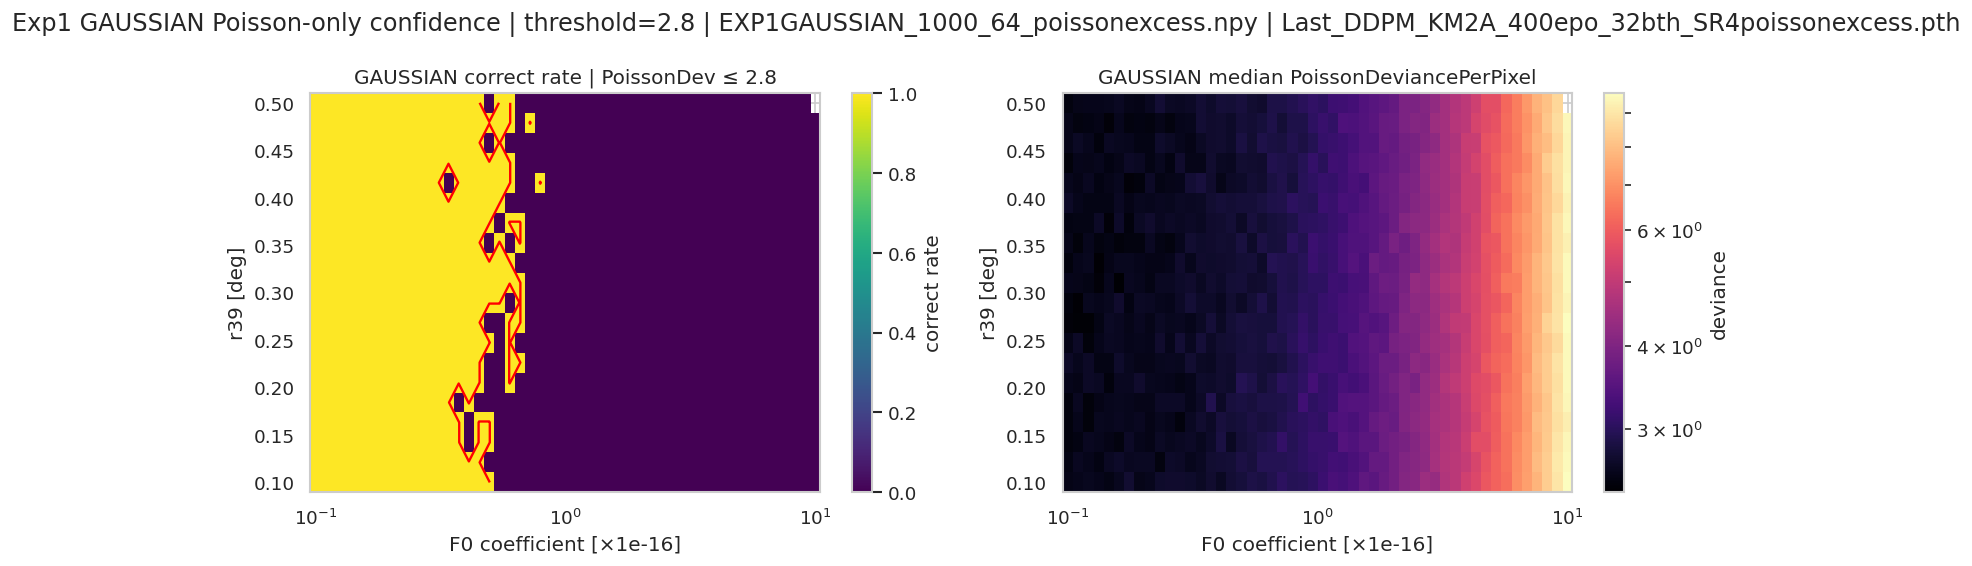

In [20]:
# 2D phase map: GAUSSIAN correct rate (Poisson-only) over flux × r39.
from matplotlib.colors import LogNorm

pivot_poisson_correct = poisson_agg.pivot(
    index='scale_r39_deg', columns='flux_F0', values='correct_rate'
).sort_index()
pivot_poisson_dev = poisson_agg.pivot(
    index='scale_r39_deg', columns='flux_F0', values='median_poisson_deviance'
).sort_index()

flux_values = pivot_poisson_correct.columns.to_numpy()
r39_values = pivot_poisson_correct.index.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

im0 = axes[0].pcolormesh(
    flux_values, r39_values, pivot_poisson_correct.values,
    cmap='viridis', vmin=0, vmax=1, shading='auto',
)
axes[0].set_xscale('log')
axes[0].set_xlabel('F0 coefficient [\u00d71e-16]')
axes[0].set_ylabel('r39 [deg]')
axes[0].set_title(f'{EXP1_SOURCE_TYPE} correct rate | PoissonDev \u2264 {POISSON_DEVIANCE_THRESHOLD}')
fig.colorbar(im0, ax=axes[0], label='correct rate')
try:
    cs = axes[0].contour(flux_values, r39_values, pivot_poisson_correct.values,
                          levels=[0.95], colors='red', linewidths=1.4)
    axes[0].clabel(cs, fmt='95%')
except Exception as exc:
    print('contour skipped:', exc)

# Log-scaled median PoissonDeviancePerPixel for context.
dev_data = pivot_poisson_dev.values
dev_min = np.nanmin(dev_data[dev_data > 0]) if np.any(dev_data > 0) else 1e-4
dev_max = np.nanmax(dev_data) if np.any(np.isfinite(dev_data)) else 1.0
im1 = axes[1].pcolormesh(
    flux_values, r39_values, dev_data,
    cmap='magma', norm=LogNorm(vmin=max(dev_min, 1e-4), vmax=max(dev_max, 1e-3)),
    shading='auto',
)
axes[1].set_xscale('log')
axes[1].set_xlabel('F0 coefficient [\u00d71e-16]')
axes[1].set_ylabel('r39 [deg]')
axes[1].set_title(f'{EXP1_SOURCE_TYPE} median PoissonDeviancePerPixel')
fig.colorbar(im1, ax=axes[1], label='deviance')

fig.suptitle(
    f'Exp1 {EXP1_SOURCE_TYPE} Poisson-only confidence | threshold={POISSON_DEVIANCE_THRESHOLD} | '
    f'{DATA_NAME} | {MODEL_WEIGHT_NAME}'
)
fig.tight_layout()
phase_path = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_poisson_confidence_phase_map.png'
fig.savefig(phase_path, dpi=300, bbox_inches='tight')
print(f'Saved Poisson-only phase map: {phase_path}')
plt.show()


Saved per-r39 Poisson-only curves: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_poisson_correct_rate_curves.png


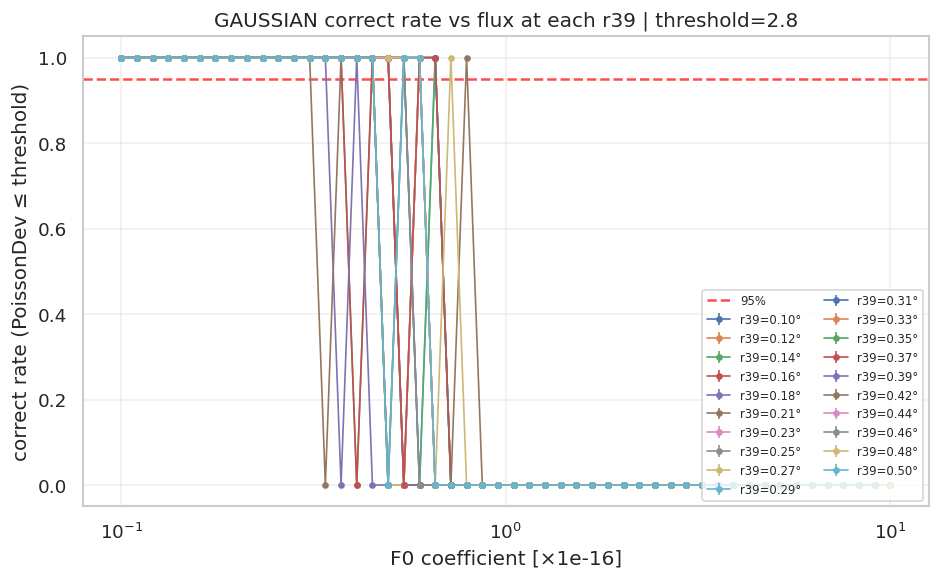

Saved Poisson-only 95% flux thresholds per r39: /root/LHAI_KM2A/saves/EVAL/Exp1_ParametricMorphologyReconstruction/GAUSSIAN/Exp1_GAUSSIAN_poisson_95pct_flux_threshold_by_r39.csv


,scale_r39_deg,flux_threshold_95pct
0,0.100000,0.542868
1,0.121053,0.494171
2,0.142105,0.409492
3,0.163158,0.409492
4,0.184211,0.372759
5,0.205263,0.494171
6,0.226316,0.494171
7,0.247368,0.542868
8,0.268421,0.494171
9,0.289474,0.596362


In [21]:
# Per-r39 correct-rate curves (Poisson-only) vs flux, with 95% line.
fig, ax = plt.subplots(figsize=(8, 5))
for r39_val, group in poisson_agg.groupby('scale_r39_deg'):
    g = group.sort_values('flux_F0')
    ax.errorbar(g['flux_F0'], g['correct_rate'], yerr=g['correct_rate_err'],
                marker='.', linewidth=1, label=f'r39={r39_val:.2f}\u00b0')
ax.axhline(0.95, linestyle='--', color='red', alpha=0.7, label='95%')
ax.set_xscale('log')
ax.set_xlabel('F0 coefficient [\u00d71e-16]')
ax.set_ylabel('correct rate (PoissonDev \u2264 threshold)')
ax.set_ylim(-0.05, 1.05)
ax.set_title(f'{EXP1_SOURCE_TYPE} correct rate vs flux at each r39 | threshold={POISSON_DEVIANCE_THRESHOLD}')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='lower right')
fig.tight_layout()
curve_path = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_poisson_correct_rate_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
print(f'Saved per-r39 Poisson-only curves: {curve_path}')
plt.show()

# Smallest flux that achieves >= 95% Poisson-correct rate at each r39.
poisson_thresholds = []
for r39_val, group in poisson_agg.groupby('scale_r39_deg'):
    g = group.sort_values('flux_F0')
    above = g[g['correct_rate'] <= 0.95]
    flux_thr = float(above['flux_F0'].min()) if not above.empty else float('nan')
    poisson_thresholds.append({'scale_r39_deg': float(r39_val), 'flux_threshold_95pct': flux_thr})
poisson_thresholds = (
    pd.DataFrame(poisson_thresholds)
    .sort_values('scale_r39_deg')
    .reset_index(drop=True)
)
poisson_thresholds_csv = OUTPUT_DIR / f'Exp1_{EXP1_SOURCE_TYPE}_poisson_95pct_flux_threshold_by_r39.csv'
poisson_thresholds.to_csv(poisson_thresholds_csv, index=False)
print(f'Saved Poisson-only 95% flux thresholds per r39: {poisson_thresholds_csv}')
poisson_thresholds
